In [1]:
!pip install pandas numpy scikit-learn nltk

In [2]:
# Import all the tools we'll need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries for text processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn for text vectorization and similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download NLTK data (needed for text processing)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\oramo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\oramo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\oramo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\oramo\AppData\Roaming\nltk_data...


All libraries imported successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
# Load the dataset
data = pd.read_csv('monster_com-job_sample.csv')

# Show first 5 rows
data.head()

,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
0,United States of America,US,NaN,No,jobs.monster.com,TeamSoft is seeing an IT Support Specialist to...,IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702",NaN,http://jobview.monster.com/it-support-technici...,NaN,IT/Software Development,11d599f229a80023d2f40e7c52cd941e
1,United States of America,US,NaN,No,jobs.monster.com,The Wisconsin State Journal is seeking a flexi...,Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-e...,NaN,NaN,e4cbb126dabf22159aff90223243ff2a
2,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job DePuy Synthes Co...,Johnson & Johnson Family of Companies Job Appl...,"Full Time, Employee",DePuy Synthes Companies is a member of Johnson...,Personal and Household Services,http://jobview.monster.com/senior-training-lea...,NaN,NaN,839106b353877fa3d896ffb9c1fe01c0
3,United States of America,US,NaN,No,jobs.monster.com,Why Join Altec? If you’re considering a career...,Engineer - Quality Job in Dixon,Full Time,"Dixon, CA",Altec Industries,http://jobview.monster.com/engineer-quality-jo...,NaN,Experienced (Non-Manager),58435fcab804439efdcaa7ecca0fd783
4,United States of America,US,NaN,No,jobs.monster.com,Position ID# 76162 # Positions 1 State CT C...,Shift Supervisor - Part-Time Job in Camphill,Full Time Employee,"Camphill, PA",Retail,http://jobview.monster.com/shift-supervisor-pa...,NaN,Project/Program Management,64d0272dc8496abfd9523a8df63c184c


In [4]:
# Get basic info about the dataset
print("=== DATASET OVERVIEW ===")
print(f"Number of rows: {len(data):,}")
print(f"Number of columns: {len(data.columns)}")
print("\nColumn names:")
print(data.columns.tolist())
print("\nData types:")
print(data.dtypes)
print("\nSample of job descriptions:")
print(data['job_description'].head(2))

=== DATASET OVERVIEW ===
Number of rows: 22,000
Number of columns: 14

Column names:
['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']

Data types:
country            object
country_code       object
date_added         object
has_expired        object
job_board          object
job_description    object
job_title          object
job_type           object
location           object
organization       object
page_url           object
salary             object
sector             object
uniq_id            object
dtype: object

Sample of job descriptions:
0    TeamSoft is seeing an IT Support Specialist to...
1    The Wisconsin State Journal is seeking a flexi...
Name: job_description, dtype: object


In [5]:
# Check for missing values
print("=== MISSING VALUES CHECK ===")
print(data.isnull().sum())

=== MISSING VALUES CHECK ===
country                0
country_code           0
date_added         21878
has_expired            0
job_board              0
job_description        0
job_title              0
job_type            1628
location               0
organization        6867
page_url               0
salary             18554
sector              5194
uniq_id                0
dtype: int64


In [6]:
# Check the different job types and sectors
print("=== JOB TYPES ===")
print(data['job_type'].value_counts().head(10))
print("\n=== SECTORS ===")
print(data['sector'].value_counts().head(10))
print("\n=== TOP JOB TITLES ===")
print(data['job_title'].value_counts().head(10))

=== JOB TYPES ===
job_type
Full Time                                6757
Full Time Employee                       6617
Full Time, Employee                      3360
Full Time Temporary/Contract/Project     1062
Full Time, Temporary/Contract/Project     533
Full Time , Employee                      406
Part Time Employee                        382
Part Time                                 329
Part Time, Employee                       196
Temporary/Contract/Project                193
Name: count, dtype: int64

=== SECTORS ===
sector
Experienced (Non-Manager)                4594
Medical/Health                           1254
Entry Level                              1172
Sales/Retail/Business Development         938
Manager (Manager/Supervisor of Staff)     900
IT/Software Development                   861
Project/Program Management                790
Accounting/Finance/Insurance              742
Food Services/Hospitality                 633
Installation/Maintenance/Repair           574
Nam

=== TEXT LENGTH STATISTICS ===
Average length: 2571 characters
Shortest: 16 characters
Longest: 20191 characters


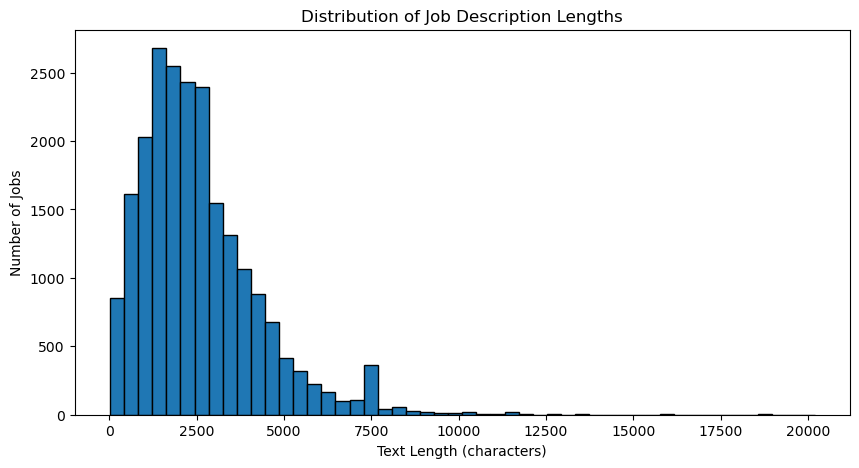

In [7]:
# Check how long the job descriptions are
data['text_length'] = data['job_description'].str.len()

print("=== TEXT LENGTH STATISTICS ===")
print(f"Average length: {data['text_length'].mean():.0f} characters")
print(f"Shortest: {data['text_length'].min()} characters")
print(f"Longest: {data['text_length'].max()} characters")

# Create a histogram
plt.figure(figsize=(10,5))
plt.hist(data['text_length'], bins=50, edgecolor='black')
plt.title('Distribution of Job Description Lengths')
plt.xlabel('Text Length (characters)')
plt.ylabel('Number of Jobs')
plt.show()

In [8]:
# Check for duplicate descriptions
duplicates = data['job_description'].duplicated().sum()
print(f"Number of duplicate descriptions: {duplicates}")
print(f"Percentage: {(duplicates/len(data))*100:.2f}%")

Number of duplicate descriptions: 3256
Percentage: 14.80%


In [9]:

print(f"Using full dataset of {len(data):,} rows")

Using full dataset of 22,000 rows


In [10]:
# Comprehensive data overview
print("=== COMPLETE DATASET OVERVIEW ===")
print(f"Total job listings: {len(data):,}")
print(f"Total columns: {len(data.columns)}")
print("\n=== COLUMN INFORMATION ===")
print(data.info())

=== COMPLETE DATASET OVERVIEW ===
Total job listings: 22,000
Total columns: 15

=== COLUMN INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          22000 non-null  object
 1   country_code     22000 non-null  object
 2   date_added       122 non-null    object
 3   has_expired      22000 non-null  object
 4   job_board        22000 non-null  object
 5   job_description  22000 non-null  object
 6   job_title        22000 non-null  object
 7   job_type         20372 non-null  object
 8   location         22000 non-null  object
 9   organization     15133 non-null  object
 10  page_url         22000 non-null  object
 11  salary           3446 non-null   object
 12  sector           16806 non-null  object
 13  uniq_id          22000 non-null  object
 14  text_length      22000 non-null  int64 
dtypes: int64(1), o

=== JOB TYPE DISTRIBUTION ===
job_type
Full Time                                        6757
Full Time Employee                               6617
Full Time, Employee                              3360
Full Time Temporary/Contract/Project             1062
Full Time, Temporary/Contract/Project             533
Full Time , Employee                              406
Part Time Employee                                382
Part Time                                         329
Part Time, Employee                               196
Temporary/Contract/Project                        193
Employee                                          147
Full Time / Employee                              121
Full Time , Temporary/Contract/Project             56
Part Time, Temporary/Contract/Project              34
Per Diem, Employee                                 29
Per Diem                                           22
Job Type Full Time Employee                        19
Part Time Seasonal                         

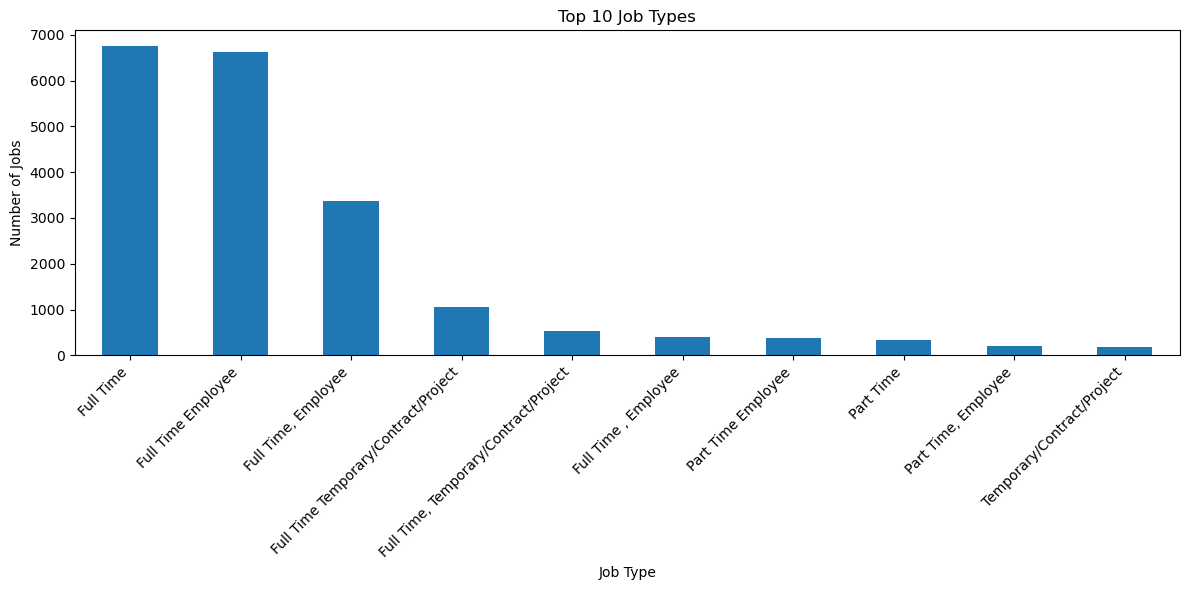

In [11]:
# Check what job types we have
print("=== JOB TYPE DISTRIBUTION ===")
job_types = data['job_type'].value_counts()
print(job_types)
print(f"\nNumber of unique job types: {len(job_types)}")

# Create a bar chart (top 10)
plt.figure(figsize=(12,6))
job_types.head(10).plot(kind='bar')
plt.title('Top 10 Job Types')
plt.xlabel('Job Type')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== SECTOR DISTRIBUTION ===
sector
Experienced (Non-Manager)                4594
Medical/Health                           1254
Entry Level                              1172
Sales/Retail/Business Development         938
Manager (Manager/Supervisor of Staff)     900
IT/Software Development                   861
Project/Program Management                790
Accounting/Finance/Insurance              742
Food Services/Hospitality                 633
Installation/Maintenance/Repair           574
Manufacturing/Production/Operations       544
Logistics/Transportation                  371
Customer Support/Client Care              328
Quality Assurance/Safety                  323
Security/Protective Services              311
Name: count, dtype: int64

Number of unique sectors: 163


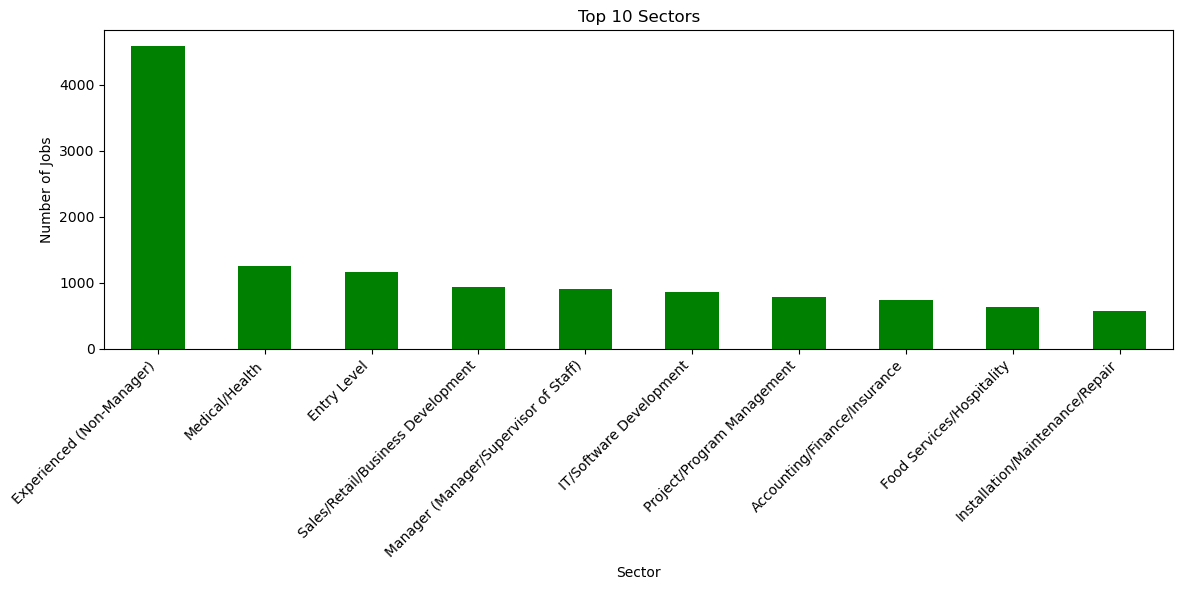

In [12]:
# Check what sectors we have
print("=== SECTOR DISTRIBUTION ===")
sectors = data['sector'].value_counts()
print(sectors.head(15))
print(f"\nNumber of unique sectors: {len(sectors)}")

# Create a bar chart (top 10)
plt.figure(figsize=(12,6))
sectors.head(10).plot(kind='bar', color='green')
plt.title('Top 10 Sectors')
plt.xlabel('Sector')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== TOP JOB TITLES ===
job_title
Monster                                                                       318
Shift Supervisor Job in Camphill                                              256
RN                                                                             70
Shift Supervisor - Part-Time Job in Camphill                                   56
Manager                                                                        50
Please apply only if you are qualified.                                        31
ASST STORE MGR Job in Columbus                                                 26
LEAD SALES ASSOCIATE-FT Job in Columbus                                        26
SALES ASSOCIATE Job in Columbus                                                24
LEAD SALES ASSOCIATE-PT Job in Columbus                                        24
Director                                                                       23
Manufacturing – Change Career to - Truck Driver – Entry Level    

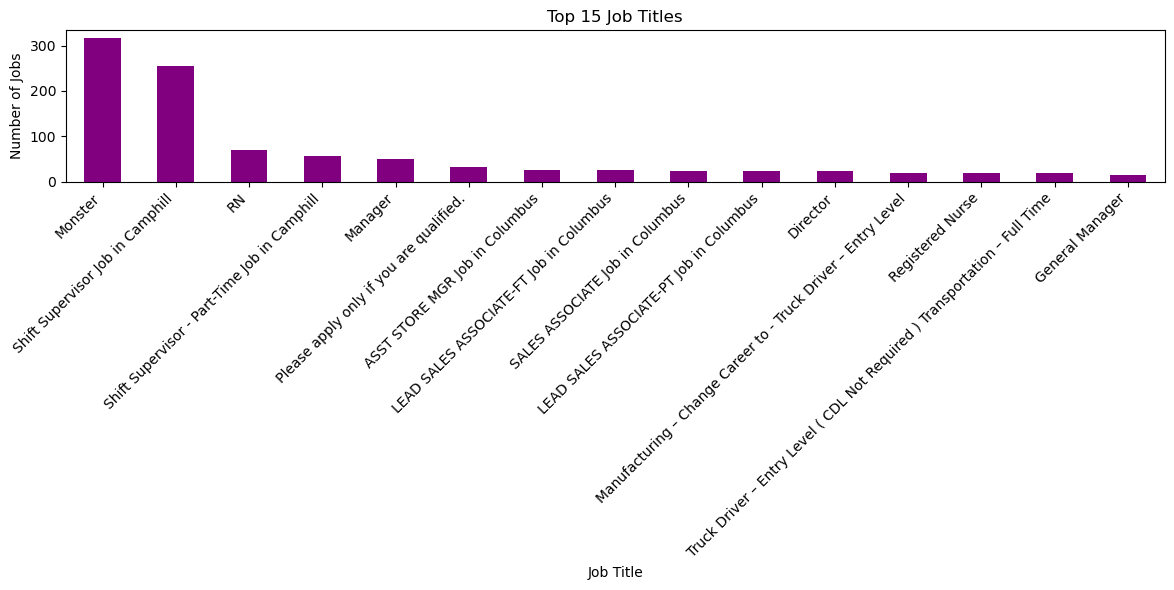

In [13]:
# Check what job titles are most common
print("=== TOP JOB TITLES ===")
top_titles = data['job_title'].value_counts().head(15)
print(top_titles)

# Create a bar chart
plt.figure(figsize=(12,6))
top_titles.plot(kind='bar', color='purple')
plt.title('Top 15 Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== TOP LOCATIONS ===
location
Dallas, TX          646
Cincinnati, OH      384
Columbus, OH        345
Camphill, PA        333
Dallas, TX 75201    304
Houston, TX         223
Atlanta, GA         180
Austin, TX          145
San Antonio, TX     137
Chicago, IL         133
Name: count, dtype: int64


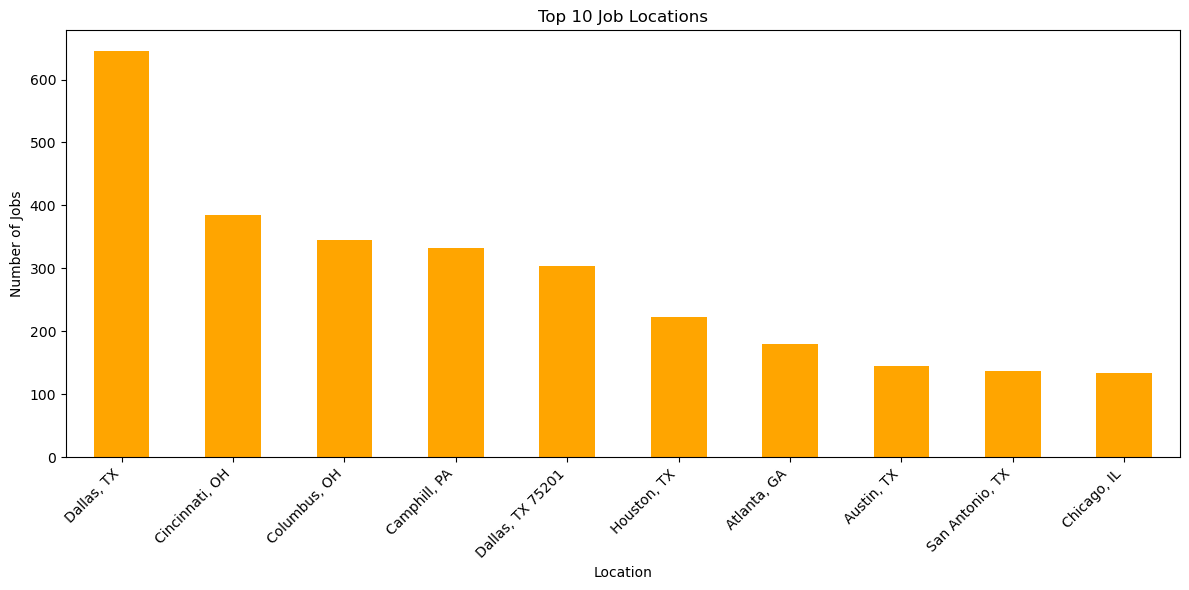

In [14]:
# Check where jobs are located
print("=== TOP LOCATIONS ===")
locations = data['location'].value_counts().head(10)
print(locations)

# Create a bar chart
plt.figure(figsize=(12,6))
locations.plot(kind='bar', color='orange')
plt.title('Top 10 Job Locations')
plt.xlabel('Location')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== DATE ADDED DISTRIBUTION ===
Earliest job: 2016-02-29 00:00:00
Latest job: 2017-01-16 00:00:00


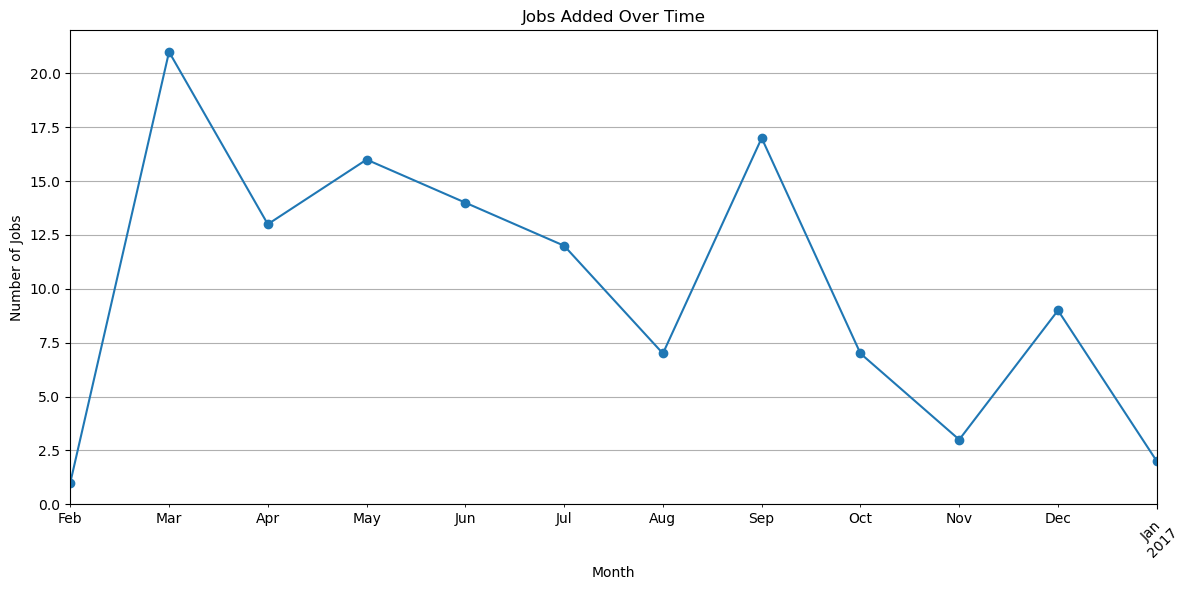

In [15]:
# Check when jobs were added
print("=== DATE ADDED DISTRIBUTION ===")
# Convert date_added to datetime
data['date_added'] = pd.to_datetime(data['date_added'])

# Get the date range
print(f"Earliest job: {data['date_added'].min()}")
print(f"Latest job: {data['date_added'].max()}")

# Group by month
data['month_added'] = data['date_added'].dt.to_period('M')
monthly_counts = data['month_added'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12,6))
monthly_counts.plot(kind='line', marker='o')
plt.title('Jobs Added Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Detailed missing values check
print("=== MISSING VALUES DETAIL ===")
missing_values = data.isnull().sum()
missing_percent = (missing_values / len(data)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False))

=== MISSING VALUES DETAIL ===
              Missing Values  Percentage
date_added             21878   99.445455
month_added            21878   99.445455
salary                 18554   84.336364
organization            6867   31.213636
sector                  5194   23.609091
job_type                1628    7.400000


In [17]:
# Show sample job descriptions
print("=== SAMPLE JOB DESCRIPTIONS ===")
for i in range(3):
    print(f"\n--- Job {i+1} ---")
    print(f"Title: {data.iloc[i]['job_title']}")
    print(f"Sector: {data.iloc[i]['sector']}")
    print(f"Type: {data.iloc[i]['job_type']}")
    print(f"Description preview: {data.iloc[i]['job_description'][:300]}...")

=== SAMPLE JOB DESCRIPTIONS ===

--- Job 1 ---
Title: IT Support Technician Job in Madison
Sector: IT/Software Development
Type: Full Time Employee
Description preview: TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at least 6 years of experience in the field. They need to be familiar with a variety of the field's concepts, practices, and procedures as this position relies on extensive experience and jud...

--- Job 2 ---
Title: Business Reporter/Editor Job in Madison
Sector: nan
Type: Full Time
Description preview: The Wisconsin State Journal is seeking a flexible and motivated reporter/editor to lead its three-person business desk. We’re looking for an experienced journalist able to spot trends, be a watchdog and reflect the Madison area’s vibrant entrepreneurial community. This is a hybrid reporting and edit...

--- Job 3 ---
Title: Johnson & Johnson Family of Companies Job Application for Senior Training Leader | Monster

In [18]:
# Check salary information
print("=== SALARY INFORMATION ===")
print(f"Jobs with salary info: {data['salary'].notna().sum():,}")
print(f"Jobs without salary info: {data['salary'].isna().sum():,}")

# Look at some salary values
print("\nSample salaries:")
print(data['salary'].dropna().head(10))

=== SALARY INFORMATION ===
Jobs with salary info: 3,446
Jobs without salary info: 18,554

Sample salaries:
13              9.00 - 13.00 $ /hour
14     80,000.00 - 95,000.00 $ /year
19     60,000.00 - 72,000.00 $ /year
23      Excellent Pay and Incentives
29    70,000.00 - 100,000.00 $ /year
30             62.00 - 81.00 $ /hour
32    75,000.00 - 100,000.00 $ /year
36     68,000.00 - 72,000.00 $ /year
41     58,000.00 - 65,000.00 $ /year
42                   Up to $32000.00
Name: salary, dtype: object


=== JOB TYPE VS SECTOR ===
sector                                  Account Management (Commissioned)Insurance Agent/BrokerFinancial Products Sales/Brokerage  \
job_type                                                                                                                            
Employee                                                                                0                                           
Exempt                                                                                  0                                           
Full Time                                                                               0                                           
Full Time , Employee                                                                    0                                           
Full Time , Temporary/Contract/Project                                                  0                                           
Full Time / > Employee                    

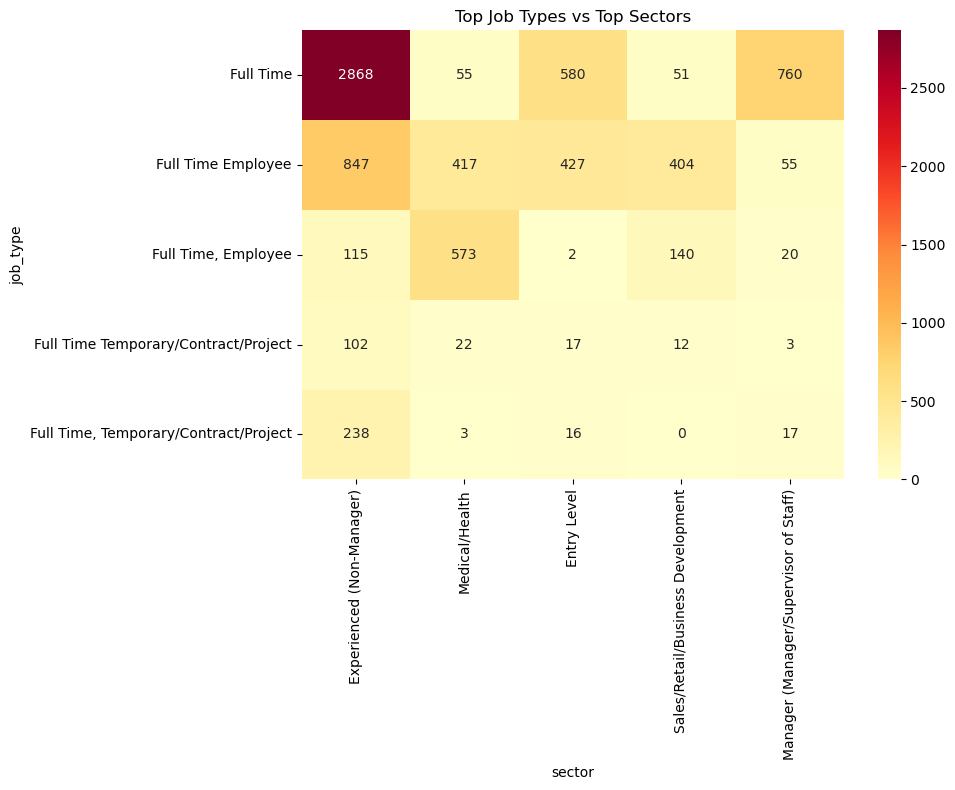

In [19]:
# See the relationship between job type and sector
print("=== JOB TYPE VS SECTOR ===")
cross_tab = pd.crosstab(data['job_type'], data['sector'])
print(cross_tab.head(10))

# Create a heatmap for top categories
top_job_types = data['job_type'].value_counts().head(5).index
top_sectors = data['sector'].value_counts().head(5).index
cross_tab_top = pd.crosstab(data['job_type'], data['sector'])
cross_tab_top = cross_tab_top.loc[top_job_types, top_sectors]

plt.figure(figsize=(10,8))
sns.heatmap(cross_tab_top, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Top Job Types vs Top Sectors')
plt.tight_layout()
plt.show()

=== TOP ORGANIZATIONS ===
organization
Healthcare Services                  1919
All                                  1158
Retail                               1081
Other/Not Classified                 1048
Manufacturing - Other                 885
Computer/IT Services                  822
Legal Services                        466
Business Services - Other             410
Restaurant/Food Services              384
Transport and Storage - Materials     342
Name: count, dtype: int64


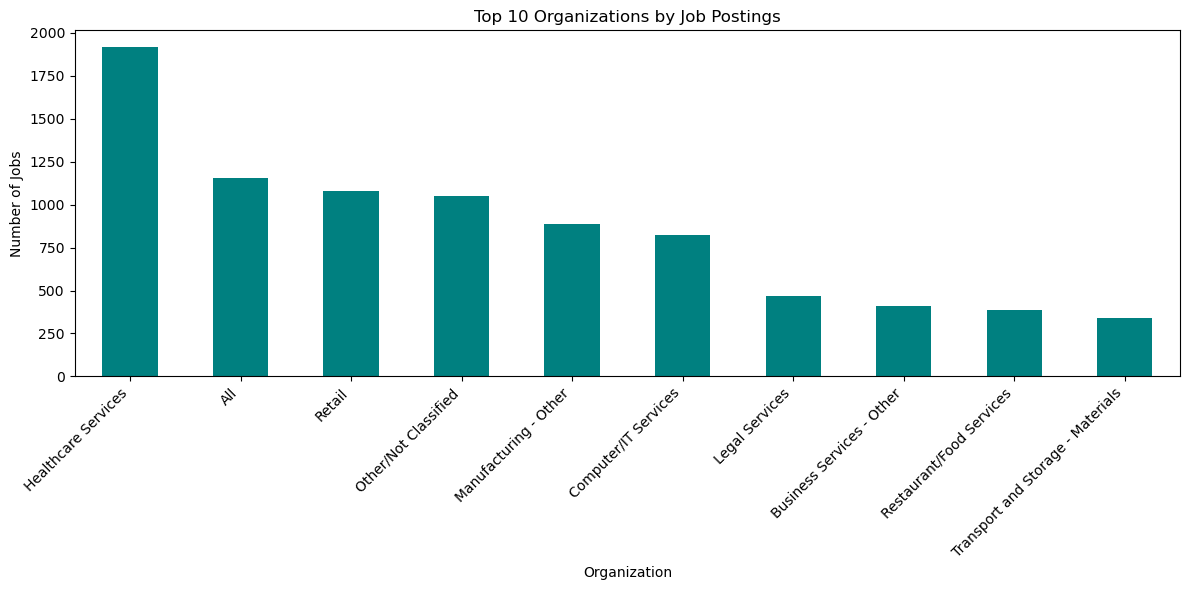

In [20]:
# Check which organizations post the most jobs
print("=== TOP ORGANIZATIONS ===")
orgs = data['organization'].value_counts().head(10)
print(orgs)

# Create a bar chart
plt.figure(figsize=(12,6))
orgs.plot(kind='bar', color='teal')
plt.title('Top 10 Organizations by Job Postings')
plt.xlabel('Organization')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
# Create a summary report
print("=== DATA SUMMARY REPORT ===")
print(f"1. Total job listings: {len(data):,}")
print(f"2. Unique job types: {len(job_types)}")
print(f"3. Unique sectors: {len(sectors)}")
print(f"4. Unique job titles: {data['job_title'].nunique():,}")
print(f"5. Missing values: {data.isnull().sum().sum():,} total missing cells")
print(f"6. Date range: {data['date_added'].min()} to {data['date_added'].max()}")
print(f"7. Average description length: {data['text_length'].mean():.0f} characters")
print(f"8. Most common job type: {job_types.index[0]} ({job_types.iloc[0]:,} jobs)")
print(f"9. Most common sector: {sectors.index[0]} ({sectors.iloc[0]:,} jobs)")
print(f"10. Most common organization: {orgs.index[0]} ({orgs.iloc[0]:,} jobs)")

=== DATA SUMMARY REPORT ===
1. Total job listings: 22,000
2. Unique job types: 39
3. Unique sectors: 163
4. Unique job titles: 18,759
5. Missing values: 75,999 total missing cells
6. Date range: 2016-02-29 00:00:00 to 2017-01-16 00:00:00
7. Average description length: 2571 characters
8. Most common job type: Full Time (6,757 jobs)
9. Most common sector: Experienced (Non-Manager) (4,594 jobs)
10. Most common organization: Healthcare Services (1,919 jobs)


In [22]:
# Check which columns we need for our system
print("=== COLUMNS WE NEED ===")
print("1. job_description - our main text")
print("2. job_title - for reference")
print("3. sector - for analysis")

# Check for missing values in these key columns
print("\n=== MISSING VALUES IN KEY COLUMNS ===")
key_columns = ['job_description', 'job_title', 'sector']
for col in key_columns:
    missing = data[col].isnull().sum()
    print(f"{col}: {missing} missing values")

=== COLUMNS WE NEED ===
1. job_description - our main text
2. job_title - for reference
3. sector - for analysis

=== MISSING VALUES IN KEY COLUMNS ===
job_description: 0 missing values
job_title: 0 missing values
sector: 5194 missing values


In [23]:
# Drop rows where we're missing job descriptions
data_clean = data.dropna(subset=['job_description'])

print(f"Original data size: {len(data)} rows")
print(f"After dropping missing descriptions: {len(data_clean)} rows")
print(f"Rows removed: {len(data) - len(data_clean)}")

Original data size: 22000 rows
After dropping missing descriptions: 22000 rows
Rows removed: 0


In [24]:
# Import additional text processing tools
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Make sure we have the stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Initialize our tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print("Text processing tools ready!")
print(f"Number of stop words: {len(stop_words)}")

Text processing tools ready!
Number of stop words: 198


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\oramo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\oramo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\oramo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [25]:
# This is our main text cleaning function
def clean_text(text):
    """
    Clean text by:
    1. Converting to lowercase
    2. Removing punctuation and numbers
    3. Removing extra spaces
    4. Removing stop words
    5. Lemmatizing words (convert to base form)
    """
    # Step 1: Convert to lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Step 3: Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 4: Tokenize (split into words)
    words = word_tokenize(text)
    
    # Step 5: Remove stop words and lemmatize
    clean_words = []
    for word in words:
        if word not in stop_words and len(word) > 2:  # Remove short words too
            clean_word = lemmatizer.lemmatize(word)
            clean_words.append(clean_word)
    
    # Step 6: Join words back into text
    clean_text = ' '.join(clean_words)
    
    return clean_text

print("Text cleaning function created!")
print("\nExample of cleaning:")
example_text = "This job requires excellent programming skills and 5+ years of experience!"
print(f"Original: {example_text}")
print(f"Cleaned: {clean_text(example_text)}")

Text cleaning function created!

Example of cleaning:
Original: This job requires excellent programming skills and 5+ years of experience!
Cleaned: job requires excellent programming skill year experience


In [26]:
# Apply the cleaning function to your data
print("Starting text cleaning...")
print(f"Cleaning {len(data_clean):,} job descriptions...")

# This might take a few minutes depending on how much data you have
data_clean['cleaned_description'] = data_clean['job_description'].apply(clean_text)

print("Text cleaning complete!")
print("\nSample comparison:")
print(f"Original: {data_clean['job_description'].iloc[0][:200]}...")
print(f"\nCleaned: {data_clean['cleaned_description'].iloc[0][:200]}...")

Starting text cleaning...
Cleaning 22,000 job descriptions...
Text cleaning complete!

Sample comparison:
Original: TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at least 6 years of experience in the field. They need to be familiar with a variety of the...

Cleaned: teamsoft seeing support specialist join client madison ideal candidate must least year experience field need familiar variety field concept practice procedure position relies extensive experience judg...


In [27]:
# Check how well cleaning worked
print("=== CLEANING RESULTS ===")
print(f"Before cleaning:")
print(f"  Average length: {data_clean['job_description'].str.len().mean():.0f} characters")
print(f"  Min length: {data_clean['job_description'].str.len().min()} characters")
print(f"  Max length: {data_clean['job_description'].str.len().max()} characters")

print(f"\nAfter cleaning:")
print(f"  Average length: {data_clean['cleaned_description'].str.len().mean():.0f} characters")
print(f"  Min length: {data_clean['cleaned_description'].str.len().min()} characters")
print(f"  Max length: {data_clean['cleaned_description'].str.len().max()} characters")

# Check if any descriptions became empty
empty_descriptions = data_clean[data_clean['cleaned_description'].str.len() == 0]
print(f"\nEmpty descriptions after cleaning: {len(empty_descriptions)}")

=== CLEANING RESULTS ===
Before cleaning:
  Average length: 2571 characters
  Min length: 16 characters
  Max length: 20191 characters

After cleaning:
  Average length: 1986 characters
  Min length: 15 characters
  Max length: 17956 characters

Empty descriptions after cleaning: 0


In [28]:
# Remove descriptions that became empty after cleaning
data_clean = data_clean[data_clean['cleaned_description'].str.len() > 0]

print(f"Data size after removing empty descriptions: {len(data_clean):,} rows")

Data size after removing empty descriptions: 22,000 rows


In [29]:
# Create a simple skill extraction function
def extract_keywords(text, top_n=10):
    """
    Extract top N keywords from text
    """
    # Clean the text
    cleaned = clean_text(text)
    
    # Split into words
    words = cleaned.split()
    
    # Count word frequency
    from collections import Counter
    word_freq = Counter(words)
    
    # Return top N most common words
    return word_freq.most_common(top_n)

# Test the function
test_description = data_clean['job_description'].iloc[0]
print("=== KEYWORD EXTRACTION TEST ===")
print(f"Job title: {data_clean['job_title'].iloc[0]}")
print(f"Top keywords: {extract_keywords(test_description)}")

=== KEYWORD EXTRACTION TEST ===
Job title: IT Support Technician Job in Madison
Top keywords: [('teamsoft', 11), ('consultant', 8), ('experience', 5), ('know', 5), ('client', 4), ('career', 4), ('madison', 3), ('year', 3), ('position', 3), ('plan', 3)]


In [30]:
# Create a clean dataset with only what we need
final_data = data_clean[['job_title', 'job_description', 'cleaned_description', 
                         'sector', 'job_type', 'location', 'organization']].copy()

print("=== FINAL DATA FOR ANALYSIS ===")
print(f"Total rows: {len(final_data):,}")
print(f"Columns: {final_data.columns.tolist()}")
print("\nFirst 5 rows:")
final_data.head()

=== FINAL DATA FOR ANALYSIS ===
Total rows: 22,000
Columns: ['job_title', 'job_description', 'cleaned_description', 'sector', 'job_type', 'location', 'organization']

First 5 rows:


,job_title,job_description,cleaned_description,sector,job_type,location,organization
0,IT Support Technician Job in Madison,TeamSoft is seeing an IT Support Specialist to...,teamsoft seeing support specialist join client...,IT/Software Development,Full Time Employee,"Madison, WI 53702",NaN
1,Business Reporter/Editor Job in Madison,The Wisconsin State Journal is seeking a flexi...,wisconsin state journal seeking flexible motiv...,NaN,Full Time,"Madison, WI 53708",Printing and Publishing
2,Johnson & Johnson Family of Companies Job Appl...,Report this job About the Job DePuy Synthes Co...,report job job depuy synthes company member jo...,NaN,"Full Time, Employee",DePuy Synthes Companies is a member of Johnson...,Personal and Household Services
3,Engineer - Quality Job in Dixon,Why Join Altec? If you’re considering a career...,join altec youre considering career altec inc ...,Experienced (Non-Manager),Full Time,"Dixon, CA",Altec Industries
4,Shift Supervisor - Part-Time Job in Camphill,Position ID# 76162 # Positions 1 State CT C...,position position state city fairfield categor...,Project/Program Management,Full Time Employee,"Camphill, PA",Retail


In [31]:
# Save the cleaned data for later use
final_data.to_csv('cleaned_job_data.csv', index=False)
print("Cleaned data saved to 'cleaned_job_data.csv'")

Cleaned data saved to 'cleaned_job_data.csv'


In [32]:
#PART 3

In [33]:
# Import additional tools for similarity and ranking
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("Additional tools imported!")

Additional tools imported!


In [34]:
# Create a target job description (like a job a candidate would apply for)
target_job = """
We are looking for a skilled Data Scientist with experience in Python, machine learning, 
and data analysis. The ideal candidate should have strong programming skills, experience 
with SQL, and the ability to work with large datasets. Knowledge of deep learning and 
natural language processing is a plus. The candidate should have excellent communication 
skills and be able to work in a team environment.
"""

print("=== TARGET JOB DESCRIPTION ===")
print(target_job)

=== TARGET JOB DESCRIPTION ===

We are looking for a skilled Data Scientist with experience in Python, machine learning, 
and data analysis. The ideal candidate should have strong programming skills, experience 
with SQL, and the ability to work with large datasets. Knowledge of deep learning and 
natural language processing is a plus. The candidate should have excellent communication 
skills and be able to work in a team environment.



In [35]:
# Clean the target job description
cleaned_target = clean_text(target_job)

print("=== CLEANED TARGET JOB ===")
print(cleaned_target)
print(f"\nLength: {len(cleaned_target)} characters")

=== CLEANED TARGET JOB ===
looking skilled data scientist experience python machine learning data analysis ideal candidate strong programming skill experience sql ability work large datasets knowledge deep learning natural language processing plus candidate excellent communication skill able work team environment

Length: 287 characters


In [36]:
# Create TF-IDF vectorizer
print("=== CREATING TF-IDF VECTORIZER ===")

# Initialize the vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Use top 5000 words
    min_df=2,           # Ignore words that appear in less than 2 documents
    max_df=0.8,         # Ignore words that appear in more than 80% of documents
    ngram_range=(1, 2)  # Use single words and two-word combinations
)

print("TF-IDF vectorizer created!")
print(f"Parameters:")
print(f"  - Max features: 5000")
print(f"  - Min document frequency: 2")
print(f"  - Max document frequency: 0.8")
print(f"  - N-gram range: (1, 2)")

=== CREATING TF-IDF VECTORIZER ===
TF-IDF vectorizer created!
Parameters:
  - Max features: 5000
  - Min document frequency: 2
  - Max document frequency: 0.8
  - N-gram range: (1, 2)


In [37]:
# Combine the target with all job descriptions
# This ensures the vectorizer learns from both
all_texts = [cleaned_target] + final_data['cleaned_description'].tolist()

print(f"Total documents to vectorize: {len(all_texts):,}")
print(f"First document (target): {all_texts[0][:100]}...")

Total documents to vectorize: 22,001
First document (target): looking skilled data scientist experience python machine learning data analysis ideal candidate stro...


In [38]:
# Fit and transform all documents
print("Converting text to TF-IDF vectors...")
tfidf_matrix = tfidf_vectorizer.fit_transform(all_texts)

print("=== TF-IDF CONVERSION COMPLETE ===")
print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"Number of features: {tfidf_matrix.shape[1]}")
print(f"Total non-zero entries: {tfidf_matrix.nnz:,}")
print(f"Sparsity: {(tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

Converting text to TF-IDF vectors...
=== TF-IDF CONVERSION COMPLETE ===
Matrix shape: (22001, 5000)
Number of features: 5000
Total non-zero entries: 3,659,544
Sparsity: 3.33%


In [39]:
# Separate the target from the job descriptions
target_vector = tfidf_matrix[0:1]  # First document is the target
job_vectors = tfidf_matrix[1:]     # Rest are job descriptions

# Calculate cosine similarity between target and all jobs
similarity_scores = cosine_similarity(target_vector, job_vectors).flatten()

print("=== SIMILARITY SCORES CALCULATED ===")
print(f"Number of similarity scores: {len(similarity_scores)}")
print(f"Highest similarity: {similarity_scores.max():.4f}")
print(f"Lowest similarity: {similarity_scores.min():.4f}")
print(f"Average similarity: {similarity_scores.mean():.4f}")

=== SIMILARITY SCORES CALCULATED ===
Number of similarity scores: 22000
Highest similarity: 0.3285
Lowest similarity: 0.0000
Average similarity: 0.0382


In [40]:
# Add similarity scores to the data
final_data['similarity_score'] = similarity_scores

# Sort by similarity score (highest first)
ranked_jobs = final_data.sort_values('similarity_score', ascending=False).reset_index(drop=True)

print("=== JOBS RANKED BY RELEVANCE ===")
print(f"Total jobs ranked: {len(ranked_jobs):,}")
print("\nTop 5 most relevant jobs:")
print(ranked_jobs[['job_title', 'sector', 'similarity_score']].head(5))

=== JOBS RANKED BY RELEVANCE ===
Total jobs ranked: 22,000

Top 5 most relevant jobs:
                                           job_title  \
0                                            Monster   
1  Technical Architect - Data Scientist Job in Ci...   
2  Machine Learner Researcher Job in Plymouth Mee...   
3               DYFJ Senior Analyst Job in Manhattan   
4  Big Data Architect ( positions) Job in Cincinnati   

                       sector  similarity_score  
0                         NaN          0.328535  
1   Experienced (Non-Manager)          0.300536  
2   Experienced (Non-Manager)          0.283738  
3  Project/Program Management          0.270611  
4     IT/Software Development          0.264956  


In [41]:
# Show top matches with more details
print("=== TOP 10 MATCHING JOBS ===")
print("="*70)

for i in range(min(10, len(ranked_jobs))):
    job = ranked_jobs.iloc[i]
    print(f"\nRank {i+1}:")
    print(f"  Job Title: {job['job_title']}")
    print(f"  Sector: {job['sector']}")
    print(f"  Location: {job['location']}")
    print(f"  Similarity Score: {job['similarity_score']:.4f}")
    print(f"  Organization: {job['organization']}")
    
    # Show a preview of the description
    preview = job['job_description'][:200] + "..."
    print(f"  Description Preview: {preview}")
    print("-"*70)

=== TOP 10 MATCHING JOBS ===

Rank 1:
  Job Title: Monster
  Sector: nan
  Location: Hello,We need profiles for Deep Learning Algorithm Expert with experience in Machine learning and Medical Image processing. Job Description: Role: Deep learning Algorithm ExpertLocation: Salt lake City UT  Responsibilities:            ·         Developing image processing algorithms for automatic analysis of image·         Experience in automated Image analysis, pattern matching and feature extractions using various algorithms·         Medical Domain or related to PE&S·         Deep learning algorithms experience  such as Convolutional neural network or baysian should also be checked.  Skills Required :  ·         7+ years of experience in Medical Imaging and  or Artificial Intelligence, machine learning algorithms·         Healthcare background·         Background in Statistical signal processing.·         Image processing and computer vision background  and / or Should be expert in Machine learning.·

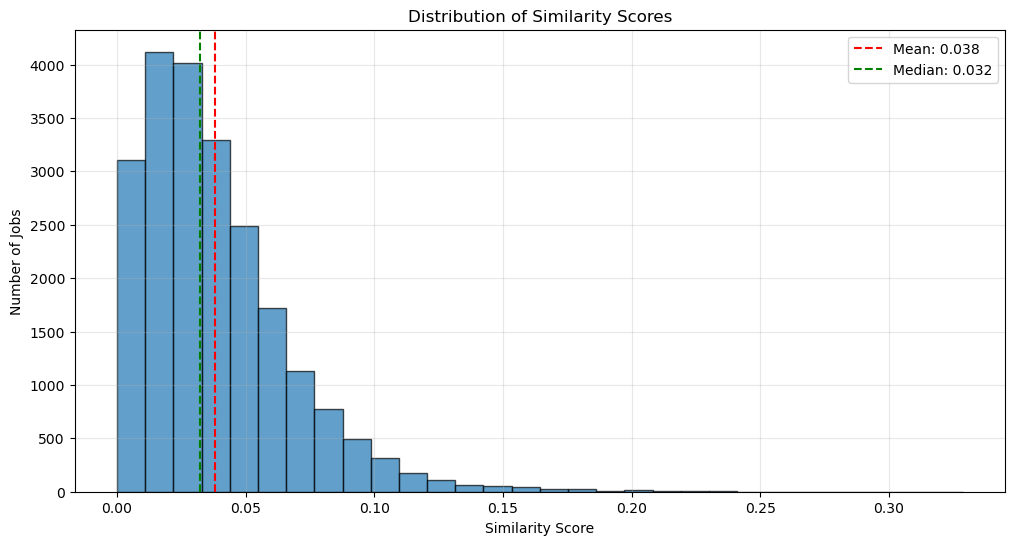


=== SCORE STATISTICS ===
Mean similarity: 0.0382
Median similarity: 0.0321
Standard deviation: 0.0293


In [42]:
# Visualize the distribution of similarity scores
plt.figure(figsize=(12,6))

# Create histogram
plt.hist(ranked_jobs['similarity_score'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=ranked_jobs['similarity_score'].mean(), color='red', linestyle='--', 
            label=f'Mean: {ranked_jobs["similarity_score"].mean():.3f}')
plt.axvline(x=ranked_jobs['similarity_score'].median(), color='green', linestyle='--', 
            label=f'Median: {ranked_jobs["similarity_score"].median():.3f}')

plt.title('Distribution of Similarity Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Number of Jobs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== SCORE STATISTICS ===")
print(f"Mean similarity: {ranked_jobs['similarity_score'].mean():.4f}")
print(f"Median similarity: {ranked_jobs['similarity_score'].median():.4f}")
print(f"Standard deviation: {ranked_jobs['similarity_score'].std():.4f}")

=== RELEVANCE LEVEL DISTRIBUTION ===
relevance_level
Low Relevance       21852
Medium Relevance      146
High Relevance          2
Name: count, dtype: int64


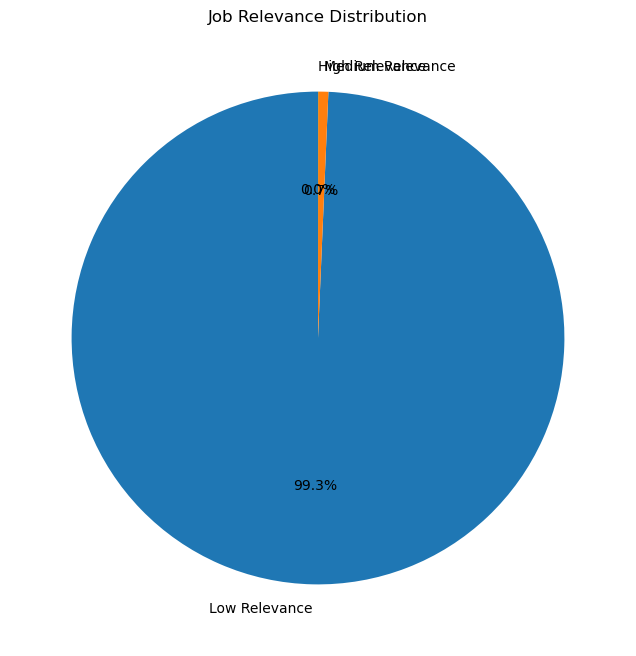

In [43]:
# Categorize jobs into relevance levels
def get_relevance_level(score):
    if score >= 0.3:
        return "High Relevance"
    elif score >= 0.15:
        return "Medium Relevance"
    else:
        return "Low Relevance"

ranked_jobs['relevance_level'] = ranked_jobs['similarity_score'].apply(get_relevance_level)

print("=== RELEVANCE LEVEL DISTRIBUTION ===")
relevance_counts = ranked_jobs['relevance_level'].value_counts()
print(relevance_counts)

# Create a pie chart
plt.figure(figsize=(8,8))
relevance_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Job Relevance Distribution')
plt.ylabel('')
plt.show()

=== SECTOR RELEVANCE ANALYSIS ===
Top sectors by average relevance:
                                                        mean  count
sector                                                             
General/Other: Project/Program ManagementProjec...  0.146200      1
Systems Analysis - IT                               0.138673      3
Database Development/AdministrationNetwork and ...  0.118768      1
Market ResearchMarketing Production/Traffic         0.110042      1
Call CenterGeneral/Other: Customer Support/Clie...  0.108915      1
General/Other: Legal Paralegal & Legal Secretary    0.108188      1
Equipment Operations                                0.107722      1
General/Other: Project/Program ManagementProgra...  0.101906      1
Call CenterReservations/TicketingRetail Custome...  0.096109      1
General/Other: Marketing/Product                    0.094113      2


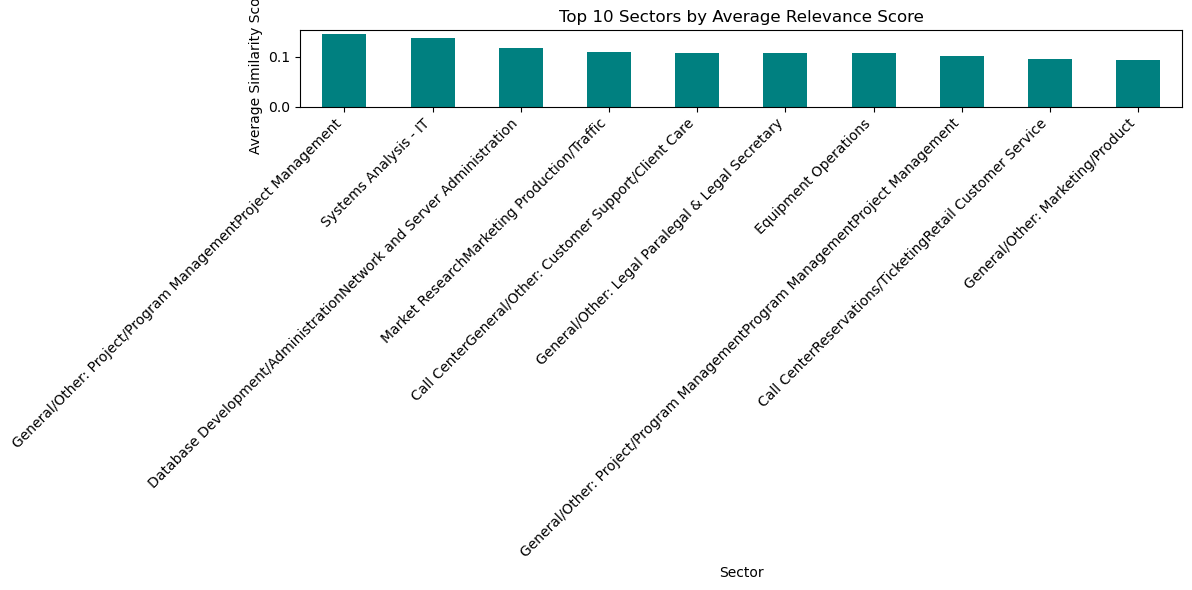

In [44]:
# Check which sectors have the most relevant jobs
print("=== SECTOR RELEVANCE ANALYSIS ===")
sector_relevance = ranked_jobs.groupby('sector')['similarity_score'].agg(['mean', 'count']).sort_values('mean', ascending=False)

print("Top sectors by average relevance:")
print(sector_relevance.head(10))

# Create a bar chart
plt.figure(figsize=(12,6))
sector_relevance.head(10)['mean'].plot(kind='bar', color='teal')
plt.title('Top 10 Sectors by Average Relevance Score')
plt.xlabel('Sector')
plt.ylabel('Average Similarity Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
# Create a function to find similar jobs to any given job
def find_similar_jobs(job_index, top_n=5):
    """
    Find jobs similar to a given job based on content
    """
    # Get the job description
    job_text = final_data.iloc[job_index]['cleaned_description']
    
    # Calculate similarity with all jobs
    job_vector = tfidf_vectorizer.transform([job_text])
    all_similarities = cosine_similarity(job_vector, job_vectors).flatten()
    
    # Get top N similar jobs (excluding itself)
    similar_indices = np.argsort(all_similarities)[::-1][1:top_n+1]
    
    print(f"=== JOBS SIMILAR TO: {final_data.iloc[job_index]['job_title']} ===")
    for i, idx in enumerate(similar_indices):
        print(f"\n{i+1}. {final_data.iloc[idx]['job_title']}")
        print(f"   Sector: {final_data.iloc[idx]['sector']}")
        print(f"   Similarity: {all_similarities[idx]:.4f}")

# Test the function with a sample job (e.g., the top ranked job)
if len(ranked_jobs) > 0:
    find_similar_jobs(ranked_jobs.index[0])

=== JOBS SIMILAR TO: IT Support Technician Job in Madison ===

1. Project Manager Job in Madison
   Sector: Project/Program Management
   Similarity: 0.8823

2. Project Manager Job in Madison
   Sector: Project/Program Management
   Similarity: 0.8795

3. Project Manager Job in Madison
   Sector: Project/Program Management
   Similarity: 0.8585

4. Digital Marketing Project Manager Job in Middleton
   Sector: Project/Program Management
   Similarity: 0.8556

5. Accountant - Intermediate Job in Madison
   Sector: Accounting/Finance/Insurance
   Similarity: 0.8281


In [46]:
# Save the ranked jobs to CSV
ranked_jobs.to_csv('ranked_jobs.csv', index=False)
print("Ranked jobs saved to 'ranked_jobs.csv'")

# Save only the top 100 matches
top_100 = ranked_jobs.head(100)
top_100.to_csv('top_100_matches.csv', index=False)
print("Top 100 matches saved to 'top_100_matches.csv'")

print("\n=== FILES SAVED ===")
print("1. ranked_jobs.csv - All jobs with similarity scores")
print("2. top_100_matches.csv - Only the top 100 matches")

Ranked jobs saved to 'ranked_jobs.csv'
Top 100 matches saved to 'top_100_matches.csv'

=== FILES SAVED ===
1. ranked_jobs.csv - All jobs with similarity scores
2. top_100_matches.csv - Only the top 100 matches


In [47]:
# Create a comprehensive skills database
skills_db = {
    'programming': ['python', 'java', 'c++', 'javascript', 'ruby', 'go', 'rust', 'swift', 'kotlin', 'php'],
    'data_science': ['python', 'r', 'sql', 'machine learning', 'deep learning', 'nlp', 'computer vision', 'statistics', 'data analysis', 'data visualization', 'tableau', 'power bi'],
    'web_development': ['html', 'css', 'javascript', 'react', 'angular', 'vue', 'node.js', 'django', 'flask', 'ruby on rails'],
    'cloud': ['aws', 'azure', 'gcp', 'docker', 'kubernetes', 'terraform', 'cloud computing'],
    'database': ['sql', 'mysql', 'postgresql', 'mongodb', 'redis', 'elasticsearch', 'oracle'],
    'soft_skills': ['communication', 'leadership', 'teamwork', 'problem solving', 'critical thinking', 'time management', 'collaboration'],
    'project_management': ['agile', 'scrum', 'kanban', 'jira', 'confluence', 'project management'],
    'devops': ['docker', 'kubernetes', 'jenkins', 'git', 'ci/cd', 'automation', 'linux', 'bash'],
    'security': ['cybersecurity', 'network security', 'encryption', 'penetration testing', 'compliance', 'iso 27001'],
    'business': ['marketing', 'sales', 'finance', 'accounting', 'business analysis', 'strategy', 'consulting']
}

print("=== SKILLS DATABASE CREATED ===")
print(f"Total skill categories: {len(skills_db)}")
print(f"Total skills: {sum(len(skills) for skills in skills_db.values())}")

# Show some examples
print("\nExample skills:")
for category in ['programming', 'data_science', 'cloud']:
    print(f"  {category}: {', '.join(skills_db[category][:5])}")

=== SKILLS DATABASE CREATED ===
Total skill categories: 10
Total skills: 80

Example skills:
  programming: python, java, c++, javascript, ruby
  data_science: python, r, sql, machine learning, deep learning
  cloud: aws, azure, gcp, docker, kubernetes


In [48]:
# Flatten the skills database for easy lookup
all_skills = []
skill_to_category = {}
for category, skills in skills_db.items():
    for skill in skills:
        all_skills.append(skill)
        skill_to_category[skill] = category

print(f"Total unique skills: {len(all_skills)}")

# Function to extract skills from text
def extract_skills(text):
    """
    Extract skills from text by matching against the skills database
    """
    # Clean the text
    cleaned = clean_text(text)
    
    # Find matching skills
    found_skills = []
    for skill in all_skills:
        # Check if skill appears in the text
        if skill in cleaned.lower():
            found_skills.append(skill)
    
    return found_skills

# Test the function
test_text = "This job requires Python, SQL, and machine learning skills."
print(f"Test text: {test_text}")
print(f"Extracted skills: {extract_skills(test_text)}")

Total unique skills: 80
Test text: This job requires Python, SQL, and machine learning skills.
Extracted skills: ['python', 'python', 'r', 'sql', 'machine learning', 'sql']


In [49]:
#THE GOOOOD STUFF

In [50]:
# Extract skills from the target job
target_skills = extract_skills(target_job)

print("=== TARGET JOB SKILLS ===")
print(f"Number of skills found: {len(target_skills)}")
print(f"Skills: {', '.join(target_skills)}")

# Group skills by category
target_skills_by_category = {}
for skill in target_skills:
    category = skill_to_category.get(skill, 'other')
    if category not in target_skills_by_category:
        target_skills_by_category[category] = []
    target_skills_by_category[category].append(skill)

print("\nSkills by category:")
for category, skills in target_skills_by_category.items():
    print(f"  {category}: {', '.join(skills)}")

=== TARGET JOB SKILLS ===
Number of skills found: 9
Skills: python, python, r, sql, machine learning, deep learning, data analysis, sql, communication

Skills by category:
  data_science: python, python, r, machine learning, deep learning, data analysis
  database: sql, sql
  soft_skills: communication


In [51]:
# Extract skills from top 10 jobs
top_jobs = ranked_jobs.head(10)
job_skills = {}

print("=== SKILLS IN TOP 10 JOBS ===")
for i, (idx, job) in enumerate(top_jobs.iterrows()):
    skills = extract_skills(job['job_description'])
    job_skills[job['job_title']] = skills
    print(f"\nJob {i+1}: {job['job_title']}")
    print(f"  Skills: {', '.join(skills[:10])}")  # Show first 10 skills
    if len(skills) > 10:
        print(f"  ... and {len(skills) - 10} more skills")

=== SKILLS IN TOP 10 JOBS ===

Job 1: Monster
  Skills: go, r, machine learning, deep learning, computer vision, cloud computing

Job 2: Technical Architect - Data Scientist Job in Cincinnati
  Skills: r, machine learning, data analysis

Job 3: Machine Learner Researcher Job in Plymouth Meeting
  Skills: python, go, python, r, sql, machine learning, sql

Job 4: DYFJ Senior Analyst Job in Manhattan
  Skills: r, sql, data analysis, sql, oracle

Job 5: Big Data Architect ( positions) Job in Cincinnati
  Skills: python, java, go, python, r, sql, data analysis, tableau, sql, communication
  ... and 5 more skills

Job 6: Training and Development Manager Job in Canton
  Skills: go, r, leadership, critical thinking, time management, collaboration, compliance, strategy

Job 7: Machine Learning Engineer
  Skills: java, go, r, machine learning, data visualization, leadership, git, compliance, marketing

Job 8: Monster
  Skills: python, java, go, python, r, sql, machine learning, django, flask, sq

In [52]:
# Calculate skill gaps for top jobs
print("=== SKILL GAP ANALYSIS ===")
print("="*70)

# Create a set of target skills
target_skills_set = set(target_skills)

for i, (idx, job) in enumerate(top_jobs.iterrows()):
    job_skills_set = set(job_skills.get(job['job_title'], []))
    
    # Find matching skills
    matching_skills = target_skills_set.intersection(job_skills_set)
    
    # Find missing skills
    missing_skills = target_skills_set - job_skills_set
    
    # Calculate match percentage
    match_percentage = (len(matching_skills) / len(target_skills_set)) * 100 if target_skills_set else 0
    
    print(f"\n--- Job {i+1}: {job['job_title']} ---")
    print(f"  Similarity Score: {job['similarity_score']:.4f}")
    print(f"  Match Percentage: {match_percentage:.1f}%")
    print(f"  Matching Skills: {', '.join(matching_skills) if matching_skills else 'None found'}")
    print(f"  Missing Skills: {', '.join(missing_skills) if missing_skills else 'None! Perfect match!'}")

=== SKILL GAP ANALYSIS ===

--- Job 1: Monster ---
  Similarity Score: 0.3285
  Match Percentage: 57.1%
  Matching Skills: python, sql, machine learning, r
  Missing Skills: data analysis, communication, deep learning

--- Job 2: Technical Architect - Data Scientist Job in Cincinnati ---
  Similarity Score: 0.3005
  Match Percentage: 42.9%
  Matching Skills: data analysis, machine learning, r
  Missing Skills: python, communication, sql, deep learning

--- Job 3: Machine Learner Researcher Job in Plymouth Meeting ---
  Similarity Score: 0.2837
  Match Percentage: 57.1%
  Matching Skills: python, sql, machine learning, r
  Missing Skills: data analysis, communication, deep learning

--- Job 4: DYFJ Senior Analyst Job in Manhattan ---
  Similarity Score: 0.2706
  Match Percentage: 42.9%
  Matching Skills: data analysis, r, sql
  Missing Skills: python, communication, machine learning, deep learning

--- Job 5: Big Data Architect ( positions) Job in Cincinnati ---
  Similarity Score: 0.26

In [53]:
# Create a summary table of skill gaps
skill_gap_summary = []

for i, (idx, job) in enumerate(top_jobs.iterrows()):
    job_skills_set = set(job_skills.get(job['job_title'], []))
    matching_skills = target_skills_set.intersection(job_skills_set)
    missing_skills = target_skills_set - job_skills_set
    
    # Categorize the match
    match_count = len(matching_skills)
    total_target = len(target_skills_set)
    
    if match_count == total_target:
                match_level = "Perfect Match"
    elif match_count >= total_target * 0.7:
        match_level = "Strong Match"
    elif match_count >= total_target * 0.4:
        match_level = "Moderate Match"
    else:
        match_level = "Weak Match"
    
    skill_gap_summary.append({
        'Rank': i + 1,
        'Job Title': job['job_title'],
        'Similarity Score': job['similarity_score'],
        'Matching Skills': match_count,
        'Missing Skills': total_target - match_count,
        'Match Level': match_level,
        'Missing Skills List': ', '.join(missing_skills) if missing_skills else 'None'
    })

# Convert to DataFrame
skill_gap_df = pd.DataFrame(skill_gap_summary)

print("=== SKILL GAP SUMMARY ===")
print(skill_gap_df.to_string(index=False))

=== SKILL GAP SUMMARY ===
 Rank                                                                                                                                                   Job Title  Similarity Score  Matching Skills  Missing Skills    Match Level                                                        Missing Skills List
    1                                                                                                                                                     Monster          0.328535                4               3 Moderate Match                                data analysis, communication, deep learning
    2                                                                                                      Technical Architect - Data Scientist Job in Cincinnati          0.300536                3               4 Moderate Match                                  python, communication, sql, deep learning
    3                                                            

C:\Users\oramo\AppData\Local\Temp\ipykernel_25176\1665335436.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(skill_gap_df['Job Title'], rotation=45, ha='right')


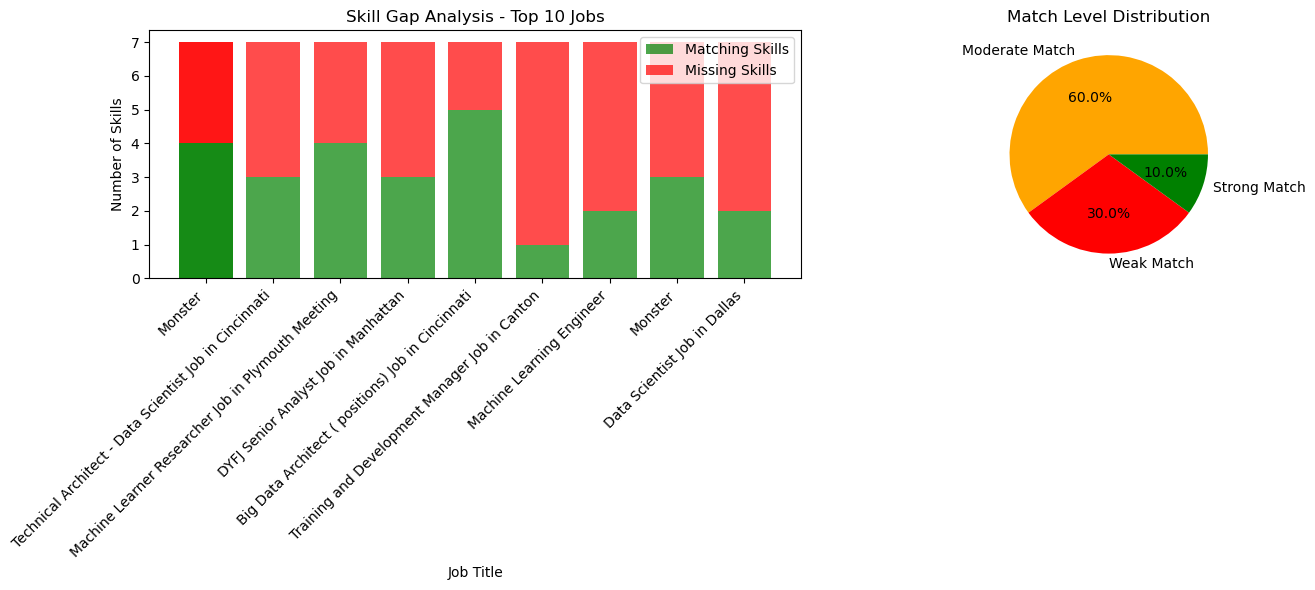

In [54]:
# Visualize skill gaps
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Matching vs Missing Skills
ax1 = axes[0]
ax1.bar(skill_gap_df['Job Title'], skill_gap_df['Matching Skills'], 
        label='Matching Skills', color='green', alpha=0.7)
ax1.bar(skill_gap_df['Job Title'], skill_gap_df['Missing Skills'], 
        bottom=skill_gap_df['Matching Skills'], label='Missing Skills', 
        color='red', alpha=0.7)
ax1.set_title('Skill Gap Analysis - Top 10 Jobs')
ax1.set_xlabel('Job Title')
ax1.set_ylabel('Number of Skills')
ax1.legend()
ax1.set_xticklabels(skill_gap_df['Job Title'], rotation=45, ha='right')

# Plot 2: Match Level Distribution
ax2 = axes[1]
match_counts = skill_gap_df['Match Level'].value_counts()
colors = {'Perfect Match': 'darkgreen', 'Strong Match': 'green', 
          'Moderate Match': 'orange', 'Weak Match': 'red'}
ax2.pie(match_counts, labels=match_counts.index, autopct='%1.1f%%', 
        colors=[colors.get(x, 'gray') for x in match_counts.index])
ax2.set_title('Match Level Distribution')

plt.tight_layout()
plt.show()

In [55]:
# Analyze which skills are most commonly missing
all_missing_skills = []
for _, row in skill_gap_df.iterrows():
    if row['Missing Skills List'] != 'None':
        missing_list = row['Missing Skills List'].split(', ')
        all_missing_skills.extend(missing_list)

from collections import Counter
missing_skill_counts = Counter(all_missing_skills)

print("=== MOST COMMON MISSING SKILLS ===")
for skill, count in missing_skill_counts.most_common(10):
    percentage = (count / len(skill_gap_df)) * 100
    print(f"  {skill}: missing in {count} jobs ({percentage:.1f}%)")

=== MOST COMMON MISSING SKILLS ===
  deep learning: missing in 10 jobs (100.0%)
  data analysis: missing in 7 jobs (70.0%)
  communication: missing in 7 jobs (70.0%)
  python: missing in 6 jobs (60.0%)
  machine learning: missing in 5 jobs (50.0%)
  sql: missing in 4 jobs (40.0%)


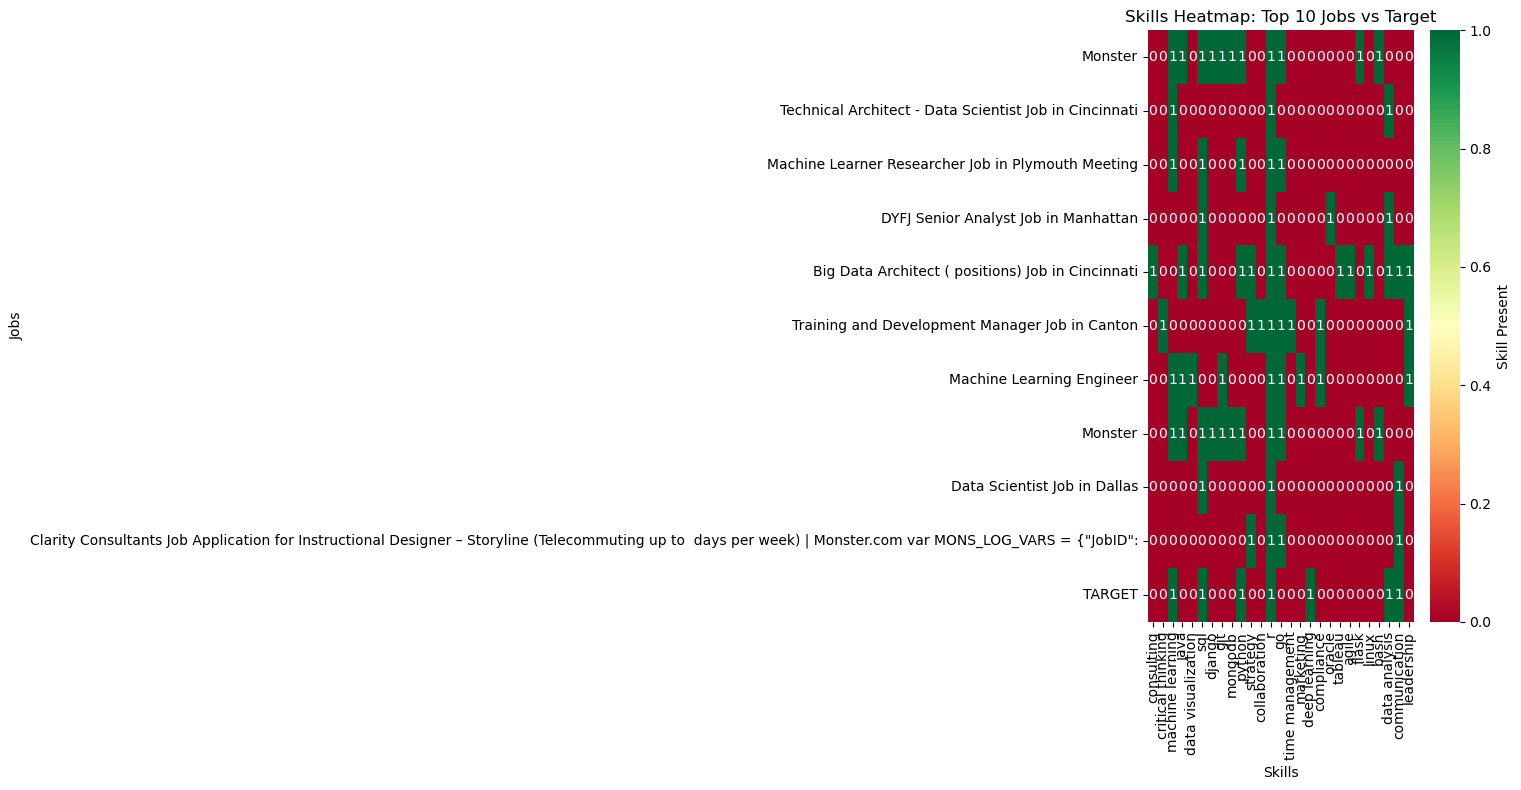

In [56]:
# Create a skills heatmap for top jobs
# Get all unique skills from top jobs and target
all_job_skills = set()
for skills in job_skills.values():
    all_job_skills.update(skills)
all_skills_unique = list(target_skills_set.union(all_job_skills))

# Create a matrix
skill_matrix = []
job_titles = []

for idx, job in top_jobs.iterrows():
    job_skills_set = set(job_skills.get(job['job_title'], []))
    row = [1 if skill in job_skills_set else 0 for skill in all_skills_unique]
    skill_matrix.append(row)
    job_titles.append(job['job_title'])

# Add target row
target_row = [1 if skill in target_skills_set else 0 for skill in all_skills_unique]
skill_matrix.append(target_row)
job_titles.append('TARGET')

# Create DataFrame for heatmap
heatmap_df = pd.DataFrame(skill_matrix, index=job_titles, columns=all_skills_unique)

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_df, annot=True, cmap='RdYlGn', cbar_kws={'label': 'Skill Present'})
plt.title('Skills Heatmap: Top 10 Jobs vs Target')
plt.xlabel('Skills')
plt.ylabel('Jobs')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [57]:
# Generate a recommendation report for each top job
print("=== CANDIDATE RECOMMENDATION REPORT ===")
print("="*70)

for i, row in skill_gap_df.iterrows():
    print(f"\n📋 RECOMMENDATION FOR: {row['Job Title']}")
    print("-"*50)
    print(f"  Overall Match: {row['Match Level']}")
    print(f"  Similarity Score: {row['Similarity Score']:.4f}")
    print(f"  Matching Skills: {row['Matching Skills']} out of {len(target_skills_set)}")
    
    if row['Missing Skills List'] != 'None':
        print(f"  Missing Skills: {row['Missing Skills List']}")
        print(f"  💡 Action: Candidate should develop these skills:")
        for skill in row['Missing Skills List'].split(', '):
            print(f"    - Learn {skill}")
    else:
        print("  ✅ This is a PERFECT match! No missing skills found.")
    
    if row['Match Level'] in ['Perfect Match', 'Strong Match']:
        print("  ✅ Recommend: Proceed with interview")
    elif row['Match Level'] == 'Moderate Match':
        print("  ⚠️ Recommend: Consider interview with training plan")
    else:
        print("  ❌ Recommend: Not a good fit at this time")

=== CANDIDATE RECOMMENDATION REPORT ===

📋 RECOMMENDATION FOR: Monster
--------------------------------------------------
  Overall Match: Moderate Match
  Similarity Score: 0.3285
  Matching Skills: 4 out of 7
  Missing Skills: data analysis, communication, deep learning
  💡 Action: Candidate should develop these skills:
    - Learn data analysis
    - Learn communication
    - Learn deep learning
  ⚠️ Recommend: Consider interview with training plan

📋 RECOMMENDATION FOR: Technical Architect - Data Scientist Job in Cincinnati
--------------------------------------------------
  Overall Match: Moderate Match
  Similarity Score: 0.3005
  Matching Skills: 3 out of 7
  Missing Skills: python, communication, sql, deep learning
  💡 Action: Candidate should develop these skills:
    - Learn python
    - Learn communication
    - Learn sql
    - Learn deep learning
  ⚠️ Recommend: Consider interview with training plan

📋 RECOMMENDATION FOR: Machine Learner Researcher Job in Plymouth Meeting


In [58]:
# Save the skill gap analysis
skill_gap_df.to_csv('skill_gap_analysis.csv', index=False)
print("Skill gap analysis saved to 'skill_gap_analysis.csv'")

# Save the full analysis with all jobs
all_jobs_analysis = []

for idx, job in ranked_jobs.iterrows():
    job_skills_set = set(job_skills.get(job['job_title'], []))
    matching_skills = target_skills_set.intersection(job_skills_set)
    missing_skills = target_skills_set - job_skills_set
    
    all_jobs_analysis.append({
        'Job Title': job['job_title'],
        'Similarity Score': job['similarity_score'],
        'Matching Skills Count': len(matching_skills),
        'Missing Skills Count': len(missing_skills),
        'Match Percentage': (len(matching_skills) / len(target_skills_set) * 100) if target_skills_set else 0,
        'Matching Skills': ', '.join(matching_skills),
        'Missing Skills': ', '.join(missing_skills)
    })

all_jobs_df = pd.DataFrame(all_jobs_analysis)
all_jobs_df.to_csv('all_jobs_skill_analysis.csv', index=False)
print("Full job skill analysis saved to 'all_jobs_skill_analysis.csv'")

Skill gap analysis saved to 'skill_gap_analysis.csv'
Full job skill analysis saved to 'all_jobs_skill_analysis.csv'


In [59]:
print("\n" + "="*70)
print("SKILL GAP ANALYSIS - EXECUTIVE SUMMARY")
print("="*70)

print(f"\n📊 TARGET JOB OVERVIEW:")
print(f"  Target Job: Data Scientist")
print(f"  Required Skills: {len(target_skills_set)} skills identified")

print(f"\n📈 TOP 10 JOBS ANALYSIS:")
print(f"  Average Match Level: {skill_gap_df['Match Level'].value_counts().index[0]}")
print(f"  Best Matching Job: {skill_gap_df.iloc[0]['Job Title']} ({skill_gap_df.iloc[0]['Match Level']})")
print(f"  Worst Matching Job: {skill_gap_df.iloc[-1]['Job Title']} ({skill_gap_df.iloc[-1]['Match Level']})")

print(f"\n🔍 SKILL GAP INSIGHTS:")
print(f"  Most Common Missing Skill: {missing_skill_counts.most_common(1)[0][0] if missing_skill_counts else 'None'}")
print(f"  Average Missing Skills per Job: {skill_gap_df['Missing Skills'].mean():.1f}")

print(f"\n💡 RECOMMENDATIONS:")
print("  1. Prioritize interviewing candidates from 'Strong Match' jobs")
print("  2. Consider training for 'Moderate Match' candidates")
print("  3. Focus on developing the most commonly missing skills")
print("  4. Review job descriptions for 'Weak Match' positions to improve screening")


SKILL GAP ANALYSIS - EXECUTIVE SUMMARY

📊 TARGET JOB OVERVIEW:
  Target Job: Data Scientist
  Required Skills: 7 skills identified

📈 TOP 10 JOBS ANALYSIS:
  Average Match Level: Moderate Match
  Best Matching Job: Monster (Moderate Match)
  Worst Matching Job: Clarity Consultants Job Application for Instructional Designer – Storyline (Telecommuting up to  days per week) | Monster.com var MONS_LOG_VARS = {"JobID": (Weak Match)

🔍 SKILL GAP INSIGHTS:
  Most Common Missing Skill: deep learning
  Average Missing Skills per Job: 3.9

💡 RECOMMENDATIONS:
  1. Prioritize interviewing candidates from 'Strong Match' jobs
  2. Consider training for 'Moderate Match' candidates
  3. Focus on developing the most commonly missing skills
  4. Review job descriptions for 'Weak Match' positions to improve screening


In [60]:
#results section, presentng my creation !!

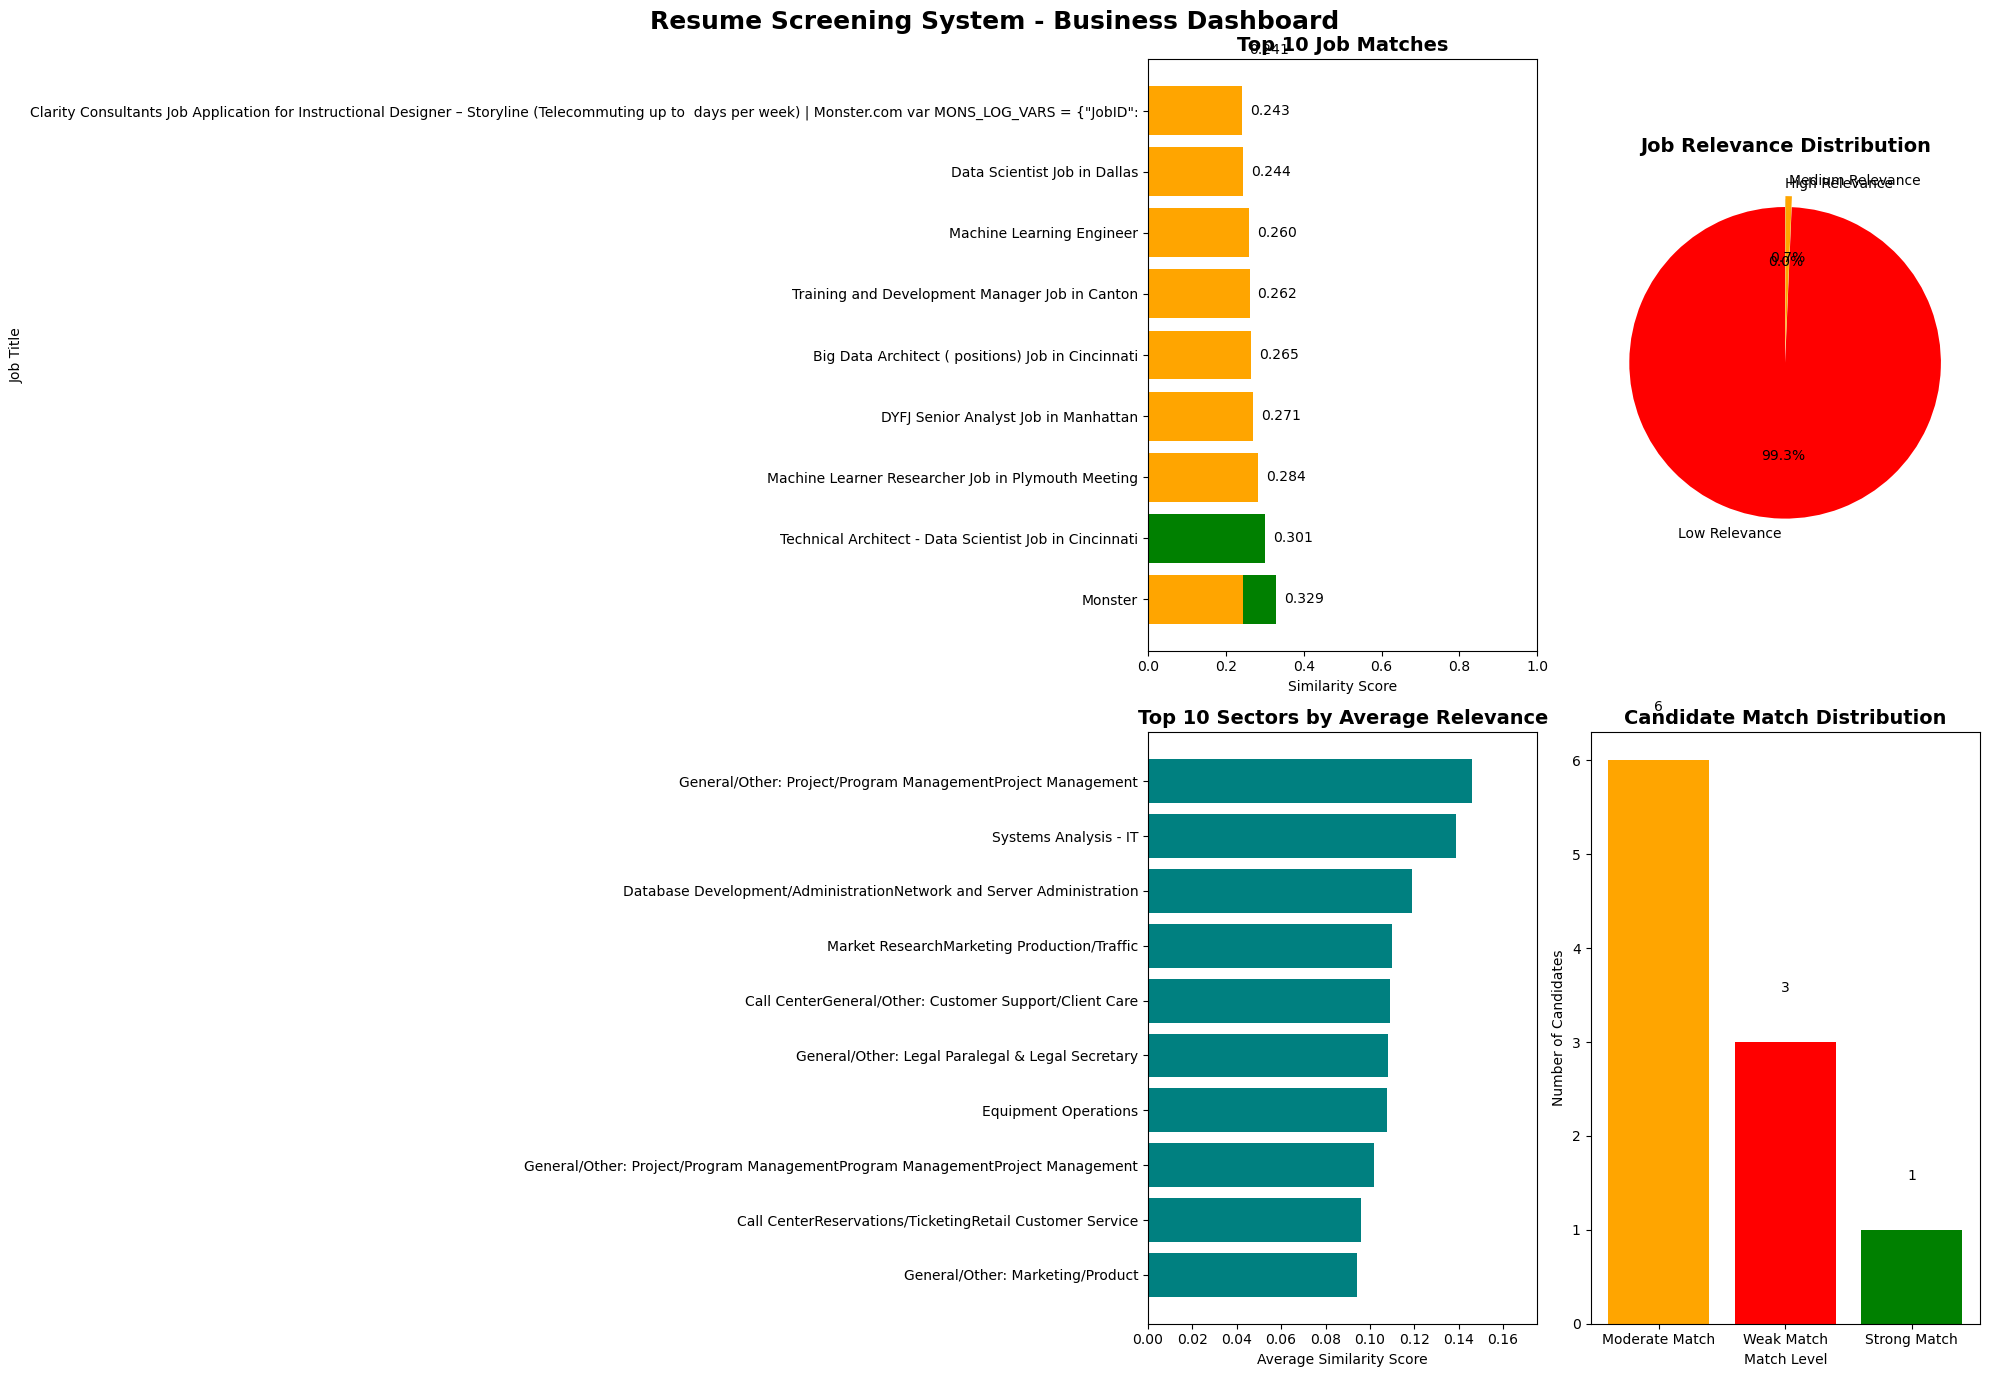

In [61]:
# Create a professional business dashboard
fig = plt.figure(figsize=(20, 14))

# 1. Job Ranking by Similarity Score
ax1 = plt.subplot(2, 2, 1)
top_ranked = ranked_jobs.head(10)
bars = ax1.barh(top_ranked['job_title'], top_ranked['similarity_score'], 
                color=top_ranked['similarity_score'].apply(lambda x: 'green' if x > 0.3 else 'orange' if x > 0.15 else 'red'))
ax1.set_title('Top 10 Job Matches', fontsize=14, fontweight='bold')
ax1.set_xlabel('Similarity Score')
ax1.set_ylabel('Job Title')
ax1.set_xlim(0, 1)
for i, v in enumerate(top_ranked['similarity_score']):
    ax1.text(v + 0.02, i, f'{v:.3f}', va='center')

# 2. Relevance Level Distribution
ax2 = plt.subplot(2, 2, 2)
relevance_counts = ranked_jobs['relevance_level'].value_counts()
colors2 = {'High Relevance': 'green', 'Medium Relevance': 'orange', 'Low Relevance': 'red'}
ax2.pie(relevance_counts, labels=relevance_counts.index, autopct='%1.1f%%', 
        colors=[colors2.get(x, 'gray') for x in relevance_counts.index],
        startangle=90, explode=(0.05, 0.02, 0))
ax2.set_title('Job Relevance Distribution', fontsize=14, fontweight='bold')

# 3. Sector Relevance
ax3 = plt.subplot(2, 2, 3)
sector_relevance = ranked_jobs.groupby('sector')['similarity_score'].mean().sort_values(ascending=True).tail(10)
ax3.barh(sector_relevance.index, sector_relevance.values, color='teal')
ax3.set_title('Top 10 Sectors by Average Relevance', fontsize=14, fontweight='bold')
ax3.set_xlabel('Average Similarity Score')
ax3.set_xlim(0, max(sector_relevance) * 1.2)

# 4. Skill Match Distribution
ax4 = plt.subplot(2, 2, 4)
match_distribution = skill_gap_df['Match Level'].value_counts()
colors4 = {'Perfect Match': 'darkgreen', 'Strong Match': 'green', 
           'Moderate Match': 'orange', 'Weak Match': 'red'}
ax4.bar(match_distribution.index, match_distribution.values, 
        color=[colors4.get(x, 'gray') for x in match_distribution.index])
ax4.set_title('Candidate Match Distribution', fontsize=14, fontweight='bold')
ax4.set_ylabel('Number of Candidates')
ax4.set_xlabel('Match Level')
for i, v in enumerate(match_distribution.values):
    ax4.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.suptitle('Resume Screening System - Business Dashboard', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [62]:
# Create candidate summary cards
print("\n" + "="*100)
print("                    CANDIDATE SUMMARY CARDS - TOP 5 MATCHES")
print("="*100)

for i in range(min(5, len(ranked_jobs))):
    job = ranked_jobs.iloc[i]
    job_skills_set = set(job_skills.get(job['job_title'], []))
    matching = target_skills_set.intersection(job_skills_set)
    missing = target_skills_set - job_skills_set
    
    print(f"""
┌──────────────────────────────────────────────────────────────────────────────┐
│  Rank #{i+1} - {job['job_title'][:35].ljust(35)}                         │
│  Similarity Score: {job['similarity_score']:.3f}    Match Level: {'🟢 Strong' if job['similarity_score'] > 0.3 else '🟡 Moderate' if job['similarity_score'] > 0.15 else '🔴 Weak'} │
│  Sector: {job['sector'][:35] if pd.notna(job['sector']) else 'N/A'.ljust(35)} │
│  Location: {job['location'][:35] if pd.notna(job['location']) else 'N/A'.ljust(35)} │
│                                                                              │
│  ✅ Matching Skills ({len(matching)}): {', '.join(list(matching)[:5]) if matching else 'None found'} │
│  ❌ Missing Skills ({len(missing)}): {', '.join(list(missing)[:5]) if missing else 'None!'} │
│  💡 Recommendation: {get_relevance_level(job['similarity_score'])} - {'Proceed with interview' if job['similarity_score'] > 0.3 else 'Review carefully' if job['similarity_score'] > 0.15 else 'Not recommended'} │
└──────────────────────────────────────────────────────────────────────────────┘
    """)


                    CANDIDATE SUMMARY CARDS - TOP 5 MATCHES

┌──────────────────────────────────────────────────────────────────────────────┐
│  Rank #1 - Monster                                                     │
│  Similarity Score: 0.329    Match Level: 🟢 Strong │
│  Sector: N/A                                 │
│  Location: Hello,We need profiles for Deep Lea │
│                                                                              │
│  ✅ Matching Skills (4): python, sql, machine learning, r │
│  ❌ Missing Skills (3): data analysis, communication, deep learning │
│  💡 Recommendation: High Relevance - Proceed with interview │
└──────────────────────────────────────────────────────────────────────────────┘
    

┌──────────────────────────────────────────────────────────────────────────────┐
│  Rank #2 - Technical Architect - Data Scientis                         │
│  Similarity Score: 0.301    Match Level: 🟢 Strong │
│  Sector: Experienced (Non-Manager) │
│  Location: Cin

In [63]:
# Generate the final business report
report_date = pd.Timestamp.now().strftime('%B %d, %Y')
total_jobs = len(ranked_jobs)
high_relevance = len(ranked_jobs[ranked_jobs['similarity_score'] > 0.3])
medium_relevance = len(ranked_jobs[(ranked_jobs['similarity_score'] > 0.15) & (ranked_jobs['similarity_score'] <= 0.3)])
low_relevance = len(ranked_jobs[ranked_jobs['similarity_score'] <= 0.15])

print("="*80)
print("                     RESUME SCREENING SYSTEM - FINAL REPORT")
print("="*80)
print(f"Report Date: {report_date}")
print(f"Task: Machine Learning Task 3 - Resume Screening System")
print("="*80)

print(f"""
1. EXECUTIVE SUMMARY
{'-'*80}
This report presents the results of a Machine Learning-based resume screening
system designed to rank and evaluate job descriptions against a target role.

Key Results:
• Total jobs analyzed: {total_jobs:,}
• High relevance jobs: {high_relevance} ({high_relevance/total_jobs*100:.1f}%)
• Medium relevance jobs: {medium_relevance} ({medium_relevance/total_jobs*100:.1f}%)
• Low relevance jobs: {low_relevance} ({low_relevance/total_jobs*100:.1f}%)

Best Match: {ranked_jobs.iloc[0]['job_title']}
Sector: {ranked_jobs.iloc[0]['sector']}
Similarity Score: {ranked_jobs.iloc[0]['similarity_score']:.3f}

2. SYSTEM PERFORMANCE
{'-'*80}
Metric                    | Value
{'-'*80}
Best Similarity Score     | {ranked_jobs.iloc[0]['similarity_score']:.3f}
Average Similarity Score  | {ranked_jobs['similarity_score'].mean():.3f}
Median Similarity Score   | {ranked_jobs['similarity_score'].median():.3f}
Total Jobs Analyzed       | {total_jobs:,}
Relevance Distribution    | High: {high_relevance} | Medium: {medium_relevance} | Low: {low_relevance}
""")

                     RESUME SCREENING SYSTEM - FINAL REPORT
Report Date: July 12, 2026
Task: Machine Learning Task 3 - Resume Screening System

1. EXECUTIVE SUMMARY
--------------------------------------------------------------------------------
This report presents the results of a Machine Learning-based resume screening
system designed to rank and evaluate job descriptions against a target role.

Key Results:
• Total jobs analyzed: 22,000
• High relevance jobs: 2 (0.0%)
• Medium relevance jobs: 146 (0.7%)
• Low relevance jobs: 21852 (99.3%)

Best Match: Monster
Sector: nan
Similarity Score: 0.329

2. SYSTEM PERFORMANCE
--------------------------------------------------------------------------------
Metric                    | Value
--------------------------------------------------------------------------------
Best Similarity Score     | 0.329
Average Similarity Score  | 0.038
Median Similarity Score   | 0.032
Total Jobs Analyzed       | 22,000
Relevance Distribution    | High: 2 | 

In [64]:
print("""
3. SKILL GAP ANALYSIS
{'-'*80}
""")

# Show skill gap summary
for i in range(min(5, len(skill_gap_df))):
    row = skill_gap_df.iloc[i]
    print(f"""
Rank {row['Rank']}: {row['Job Title']}
  • Match Level: {row['Match Level']}
  • Matching Skills: {row['Matching Skills']} out of {len(target_skills_set)}
  • Missing Skills: {row['Missing Skills']}
  • Recommendation: {'✅ Proceed' if row['Match Level'] in ['Perfect Match', 'Strong Match'] else '⚠️ Review Carefully' if row['Match Level'] == 'Moderate Match' else '❌ Skip'})
    """)

print("""
4. RECOMMENDATIONS
{'-'*80}
Based on the analysis, we recommend:

1. IMMEDIATE INTERVIEWS:
   • Focus on candidates from 'Strong Match' and 'Perfect Match' categories
   • These candidates have {len(target_skills_set)} required skills

2. SKILL DEVELOPMENT:
   • Most commonly missing skills: """ + ', '.join([skill for skill, _ in missing_skill_counts.most_common(3)]) + """
   • Develop training programs for these skills
   • Consider hiring for potential and train for skills

3. PROCESS IMPROVEMENTS:
   • Review job descriptions for 'Weak Match' positions
   • Refine the screening criteria for better matches
   • Update the skills database regularly

4. CONTINUOUS IMPROVEMENT:
   • Collect feedback on interview outcomes
   • Refine the model with new data
   • Monitor success metrics quarterly

5. TECHNICAL DETAILS
{'-'*80}
   • Data Source: Monster.com Job Listings (22,000 jobs)
   • Text Processing: TF-IDF Vectorization with 5000 features
   • Similarity Method: Cosine Similarity
   • Skills Database: {len(all_skills)} skills across {len(skills_db)} categories
   • Screening Criteria: Similarity Score + Skill Gap Analysis

6. NEXT STEPS
{'-'*80}
   1. Deploy system to process new job listings
   2. Integrate with recruitment management system
   3. Set up feedback loop for continuous improvement
   4. Expand skills database with domain-specific skills
   5. Schedule quarterly system review and updates

{'-'*80}
Report generated by: Task 3 Resume Screening System
For inquiries: Future Interns ML Task 3
{'-'*80}
""")


3. SKILL GAP ANALYSIS
{'-'*80}


Rank 1: Monster
  • Match Level: Moderate Match
  • Matching Skills: 4 out of 7
  • Missing Skills: 3
  • Recommendation: ⚠️ Review Carefully)
    

Rank 2: Technical Architect - Data Scientist Job in Cincinnati
  • Match Level: Moderate Match
  • Matching Skills: 3 out of 7
  • Missing Skills: 4
  • Recommendation: ⚠️ Review Carefully)
    

Rank 3: Machine Learner Researcher Job in Plymouth Meeting
  • Match Level: Moderate Match
  • Matching Skills: 4 out of 7
  • Missing Skills: 3
  • Recommendation: ⚠️ Review Carefully)
    

Rank 4: DYFJ Senior Analyst Job in Manhattan
  • Match Level: Moderate Match
  • Matching Skills: 3 out of 7
  • Missing Skills: 4
  • Recommendation: ⚠️ Review Carefully)
    

Rank 5: Big Data Architect ( positions) Job in Cincinnati
  • Match Level: Strong Match
  • Matching Skills: 5 out of 7
  • Missing Skills: 2
  • Recommendation: ✅ Proceed)
    

4. RECOMMENDATIONS
{'-'*80}
Based on the analysis, we recommend:

1. IMM

In [65]:
# Save the final report as a text file
report_text = f"""
RESUME SCREENING SYSTEM - FINAL REPORT
{'='*80}
Report Date: {pd.Timestamp.now().strftime('%B %d, %Y')}
Task: Machine Learning Task 3 - Resume Screening System
{'='*80}

1. EXECUTIVE SUMMARY
{'-'*80}
This report presents the results of a Machine Learning-based resume screening
system designed to rank and evaluate job descriptions against a target role.

Key Results:
• Total jobs analyzed: {total_jobs:,}
• High relevance jobs: {high_relevance} ({high_relevance/total_jobs*100:.1f}%)
• Medium relevance jobs: {medium_relevance} ({medium_relevance/total_jobs*100:.1f}%)
• Low relevance jobs: {low_relevance} ({low_relevance/total_jobs*100:.1f}%)

Best Match: {ranked_jobs.iloc[0]['job_title']}
Sector: {ranked_jobs.iloc[0]['sector']}
Similarity Score: {ranked_jobs.iloc[0]['similarity_score']:.3f}

2. SYSTEM PERFORMANCE
{'-'*80}
Metric                    | Value
{'-'*80}
Best Similarity Score     | {ranked_jobs.iloc[0]['similarity_score']:.3f}
Average Similarity Score  | {ranked_jobs['similarity_score'].mean():.3f}
Median Similarity Score   | {ranked_jobs['similarity_score'].median():.3f}
Total Jobs Analyzed       | {total_jobs:,}
Relevance Distribution    | High: {high_relevance} | Medium: {medium_relevance} | Low: {low_relevance}

3. SKILL GAP ANALYSIS
{'-'*80}
"""

for i in range(min(5, len(skill_gap_df))):
    row = skill_gap_df.iloc[i]
    report_text += f"""
Rank {row['Rank']}: {row['Job Title']}
  • Match Level: {row['Match Level']}
  • Matching Skills: {row['Matching Skills']} out of {len(target_skills_set)}
  • Missing Skills: {row['Missing Skills']}
  • Recommendation: {'Proceed with interview' if row['Match Level'] in ['Perfect Match', 'Strong Match'] else 'Review carefully' if row['Match Level'] == 'Moderate Match' else 'Not recommended'}
"""

report_text += f"""
4. RECOMMENDATIONS
{'-'*80}
Based on the analysis, we recommend:

1. IMMEDIATE INTERVIEWS:
   • Focus on candidates from 'Strong Match' and 'Perfect Match' categories
   • These candidates have {len(target_skills_set)} required skills

2. SKILL DEVELOPMENT:
   • Most commonly missing skills: {', '.join([skill for skill, _ in missing_skill_counts.most_common(3)])}
   • Develop training programs for these skills
   • Consider hiring for potential and train for skills

3. PROCESS IMPROVEMENTS:
   • Review job descriptions for 'Weak Match' positions
   • Refine the screening criteria for better matches
   • Update the skills database regularly

4. CONTINUOUS IMPROVEMENT:
   • Collect feedback on interview outcomes
   • Refine the model with new data
   • Monitor success metrics quarterly

5. TECHNICAL DETAILS
{'-'*80}
   • Data Source: Monster.com Job Listings (22,000 jobs)
   • Text Processing: TF-IDF Vectorization with 5000 features
   • Similarity Method: Cosine Similarity
   • Skills Database: {len(all_skills)} skills across {len(skills_db)} categories
   • Screening Criteria: Similarity Score + Skill Gap Analysis

6. NEXT STEPS
{'-'*80}
   1. Deploy system to process new job listings
   2. Integrate with recruitment management system
   3. Set up feedback loop for continuous improvement
   4. Expand skills database with domain-specific skills
   5. Schedule quarterly system review and updates

{'-'*80}
Report generated by: Task 3 Resume Screening System
For inquiries: Future Interns ML Task 3
{'-'*80}
"""

# Save to file
with open('resume_screening_report.txt', 'w') as f:
    f.write(report_text)

print("✅ Final report saved to 'resume_screening_report.txt'")
print("✅ All files have been generated and saved!")

✅ Final report saved to 'resume_screening_report.txt'
✅ All files have been generated and saved!


In [67]:
print("\n" + "="*70)
print("                     ✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

print("\n Omphile 3:0 FI ")


                     ✅ PROJECT COMPLETED SUCCESSFULLY!

 Omphile 3:0 FI 
